#### 共线性分析
1. 关于玉米和小肽的共线性和基因共线性的对比
2. SEP和host cds的对比

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = "/data/user_home/2023122004/FFTransformer/protein/predict_sorf/maize/Pann_Annotation.csv"
CSV_PATH1 = "/data/user_home/2023122004/FFTransformer/protein/predict_sorf/rice/Pann_Annotation.csv"

df_maize = pd.read_csv(CSV_PATH)
df_rice = pd.read_csv(CSV_PATH1)
df_maize


,ID,seqid,start,end,strand,Length_bp,Region_Category,DNA_Sequence,attributes
0,sorf_1_1,1,35062,35310,+,249,CDS,ATGGCGTCCGCGAGCTGGACGAGCTTGGCCTCTGGGCGTCGTGGAG...,ID=sorf_1_1;len=249;conf=1.00;start_codon=ATG
1,sorf_1_2,1,36108,36140,+,33,CDS,GATGATGACATACTTATCAATACCTGCAGATGA,ID=sorf_1_2;len=33;conf=1.00;start_codon=GAT
2,sorf_1_3,1,36272,36379,+,108,CDS,ATGGTGGTGTTAGCATGTTGGGACATGGAGATGTGTCATTTCCTTA...,ID=sorf_1_3;len=108;conf=1.00;start_codon=ATG
3,sorf_1_4,1,36916,36981,+,66,CDS,ATGTTCTGGGCATCAGTAAAAAAATGGTGGTTCCAGTCATTACATC...,ID=sorf_1_4;len=66;conf=1.00;start_codon=ATG
4,sorf_1_5,1,37451,37486,+,36,CDS,GAAAACAACAGGAAAAATTCTGTGTCGTTCGCCTGA,ID=sorf_1_5;len=36;conf=1.00;start_codon=GAA
...,...,...,...,...,...,...,...,...,...
64812,sorf_9_11504,9,162504130,162504171,+,42,Intergenic,ATGGCAAGCATTTGTGGGTGTTGGTGCTCGAAGGATTCCTAG,ID=sorf_9_11504;len=42;conf=1.00;start_codon=ATG
64813,sorf_9_11505,9,162505005,162505055,+,51,CDS,ATGGATCTGTTGACGAGGGTGTGGCTTATTTTGTTGAGTGGGCTAT...,ID=sorf_9_11505;len=51;conf=1.00;start_codon=ATG
64814,sorf_9_11506,9,162505216,162505248,+,33,CDS,ATGTGGAATCATCAAAGTGATTGCAAGAATTGA,ID=sorf_9_11506;len=33;conf=1.00;start_codon=ATG
64815,sorf_9_11507,9,162510493,162510552,+,60,doORF,ATGGTACCTCTCGTAATTCATCCCGTTATGGAGATTTTGATGAAGA...,ID=sorf_9_11507;len=60;conf=1.00;start_codon=ATG


In [2]:
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import os

def clean_data(df, species_name):
    df = df.copy()
    df['seqid'] = df['seqid'].astype(str)
    df['unique_id'] = f"{species_name}_" + df['ID'].astype(str)
    return df

def df_to_fasta(df, filename):
    records = []
    for index, row in df.iterrows():

        rec = SeqRecord(
            Seq(row['DNA_Sequence']),
            id=row['unique_id'],
            description=""
        )
        records.append(rec)
    
    with open(filename, "w") as output_handle:
        SeqIO.write(records, output_handle, "fasta")
    print(f"Generated {filename} with {len(records)} sequences.")

In [3]:
# # df1 = clean_data(df_maize, "maize")
# # df_to_fasta(df1, "maize.fasta")
# df_TAIR = pd.read_csv('/data/user_home/2023122004/FFTransformer/protein/predict_sorf/sl/Pann_Annotation_+.csv')
# df2 = clean_data(df_TAIR, "sl")
# df_to_fasta(df2, "/data/user_home/2023122004/FFTransformer/protein/predict_sorf/sl/sl+.fasta")

#### 1. 建库
makeblastdb -in rice.fasta -dbtype nucl -out sp2_db

#### 2. 比对 (使用 blastn)
#### e-value 设定为 1e-5，输出格式 6 是表格格式
blastn -query maize.fasta -db sp2_db -out blast_result.txt -evalue 1e-5 -outfmt 6

In [4]:
# df_TAIR=pd.read_csv('/data/user_home/2023122004/FFTransformer/protein/predict_sorf/TAIR/Pann_Annotation.csv')

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


blast_headers = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 
                 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']

blast_df = pd.read_csv("/data/user_home/2023122004/FFTransformer/protein/predict_sorf/blast/tblastx_result.txt", sep='\t', header=None, names=blast_headers)
blast_df
df_rice = df_rice.copy()
df_rice['ID'] = df_rice['ID'].astype(str).str.strip() 

if not df_rice['ID'].iloc[0].startswith('rice_'):
    df_rice['ID'] = 'rice_' + df_rice['ID']

df_maize = df_maize.copy()
df_maize['ID'] = df_maize['ID'].astype(str).str.strip()
if not df_maize['ID'].iloc[0].startswith('maize_'):
    df_maize['ID'] = 'maize_' + df_maize['ID']
blast_df['qseqid'] = blast_df['qseqid'].astype(str).str.strip()
blast_df['sseqid'] = blast_df['sseqid'].astype(str).str.strip()

merged = blast_df.merge(df_rice[['ID', 'seqid', 'start']], 
                        left_on='qseqid', right_on='ID', how='inner')
merged = merged.rename(columns={'seqid': 'chr1', 'start': 'pos1'})

final_df = merged.merge(df_maize[['ID', 'seqid', 'start']], 
                        left_on='sseqid', right_on='ID', how='inner')
final_df = final_df.rename(columns={'seqid': 'chr2', 'start': 'pos2'})

print(f"匹配成功! 最终获得同源基因对数量: {len(final_df)}")

匹配成功! 最终获得同源基因对数量: 15341


In [6]:
def get_genome_layout(df, seqid_col, pos_col):

    df[seqid_col] = df[seqid_col].astype(str)
 
    chr_sizes = df.groupby(seqid_col)[pos_col].max()
   
    def sort_key(x):
        import re
        nums = re.findall(r'\d+', x)
        if nums:
            return int(nums[0])
        return 999 

    sorted_chroms = sorted(chr_sizes.index.tolist(), key=sort_key)
    
    offset_map = {}
    current_offset = 0
    ticks = []
    boundaries = []
    
    for chrom in sorted_chroms:
        size = chr_sizes[chrom]
        offset_map[chrom] = current_offset
        boundaries.append(current_offset + size)
        ticks.append((chrom, current_offset + size/2))
        current_offset += size
        
    return offset_map, boundaries, ticks, current_offset

off1, bounds1, ticks1, len1 = get_genome_layout(df_rice, 'seqid', 'start')
off2, bounds2, ticks2, len2 = get_genome_layout(df_maize, 'seqid', 'start')

final_df['chr1'] = final_df['chr1'].astype(str)
final_df['chr2'] = final_df['chr2'].astype(str)

final_df['plot_x'] = final_df.apply(lambda row: row['pos1'] + off1.get(row['chr1'], 0), axis=1)
final_df['plot_y'] = final_df.apply(lambda row: row['pos2'] + off2.get(row['chr2'], 0), axis=1)


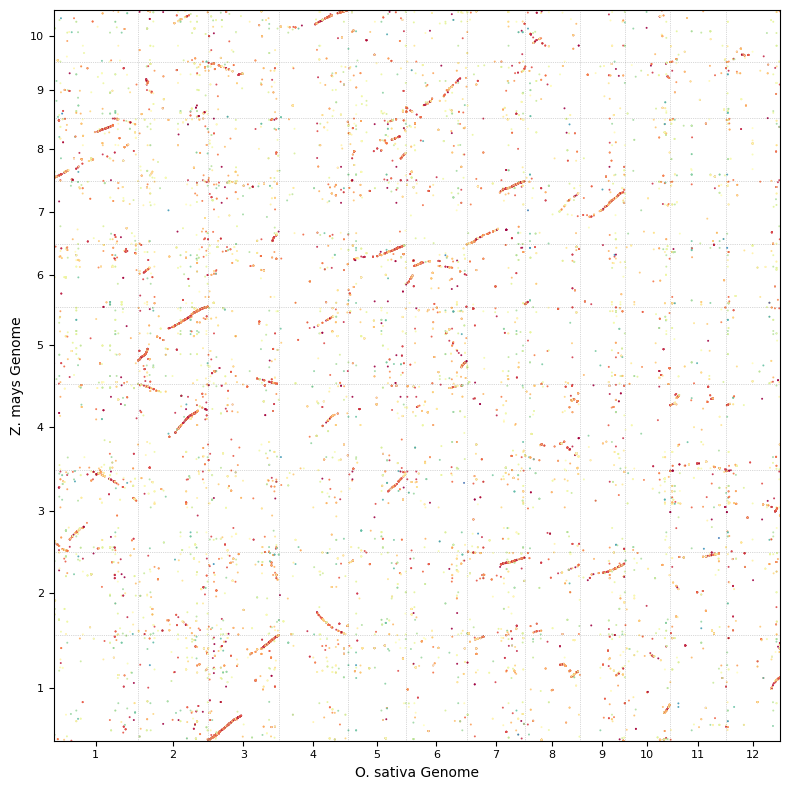

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def filter_noise(df, max_dist_1=200000, max_dist_2=200000, min_neighbors=3):
    """
    原理：真正的共线性基因，在物种1中相邻，在物种2中也应该相邻（或距离不远）。
    我们遍历每个点，看它周围有没有“邻居”。
    
    max_dist: 判定为邻居的最大碱基距离 (例如 200kb)
    min_neighbors: 至少需要几个邻居才保留
    """
    df = df.copy()
    df = df.sort_values(by=['chr1', 'pos1'])
    
    keep_indices = []
    
    # 按染色体对分组处理 (比如 Rice_Chr1 vs Maize_Chr1)
    grouped = df.groupby(['chr1', 'chr2'])
    
    for (c1, c2), group in grouped:
        if len(group) < min_neighbors:
            continue

        pos1 = group['pos1'].values
        pos2 = group['pos2'].values
        indices = group.index.values

        diff1 = np.abs(np.diff(pos1))
        diff2 = np.abs(np.diff(pos2))
        good_links = (diff1 < max_dist_1) & (diff2 < max_dist_2)
        mask = np.zeros(len(group), dtype=bool)
        mask[:-1] |= good_links 
        mask[1:] |= good_links  

        if mask.sum() >= min_neighbors:
            keep_indices.extend(indices[mask])

    return df.loc[keep_indices]

clean_df = final_df

plt.figure(figsize=(8, 8))
ax = plt.gca()
sc = ax.scatter(clean_df['plot_x'], clean_df['plot_y'], 
                c=clean_df['pident'], cmap='Spectral_r', 
                s=2, alpha=0.9, edgecolors='none') 
for b in bounds1:
    ax.axvline(x=b, color='black', linestyle=':', linewidth=0.5, alpha=0.3)
for b in bounds2:
    ax.axhline(y=b, color='black', linestyle=':', linewidth=0.5, alpha=0.3)

ax.set_xticks([x[1] for x in ticks1])
ax.set_xticklabels([x[0].replace('rice_', '') for x in ticks1],  fontsize=8) 

ax.set_yticks([x[1] for x in ticks2])
ax.set_yticklabels([x[0].replace('maize_', '') for x in ticks2], fontsize=8)

ax.set_xlabel("O. sativa Genome")
ax.set_ylabel("Z. mays Genome")
# ax.set_title(f"Synteny Plot")

# # 颜色条
# cbar = plt.colorbar(sc, fraction=0.03, pad=0.04)
# cbar.set_label('Identity (%)')

ax.set_xlim(0, len1)
ax.set_ylim(0, len2)

plt.tight_layout()

# plt.savefig('RandM.svg',dpi=1300)
# plt.savefig('RandM.png',dpi=1300)
# plt.savefig('RandM.pdf',dpi=1300)
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import re

def parse_gff_simplified(gff_file, feature_type='CDS'):
    data = []
    # 预编译正则，提高效率
    id_pattern = re.compile(r'ID=([^;]+)')
    
    with open(gff_file, 'r') as f:
        for line in f:
            if line.startswith('#'): continue
            parts = line.strip().split('\t')
            if len(parts) < 9: continue
            if parts[2] != feature_type: continue
            
            chrom = parts[0]
            
            start = int(parts[3])
            attributes = parts[8]
            
            match = id_pattern.search(attributes)
            if match:
                gene_id = match.group(1)
                data.append({'ID': gene_id, 'seqid': chrom, 'start': start})
    
    return pd.DataFrame(data)

def filter_noise(df, max_dist=500000, min_neighbors=5):
    """
    共线性去噪算法：保留邻居也匹配的点。
    对于 CDS (基因密度大)，max_dist 可以设大一点 (如 500kb)，
    min_neighbors 也可以适当提高 (如 5)。
    """
    df = df.copy().sort_values(by=['chr1', 'pos1'])
    keep_indices = []
    grouped = df.groupby(['chr1', 'chr2'])
    
    for _, group in grouped:
        if len(group) < min_neighbors: continue
        
        pos1 = group['pos1'].values
        pos2 = group['pos2'].values
        diff1 = np.abs(np.diff(pos1))
        diff2 = np.abs(np.diff(pos2))
        
        good_links = (diff1 < max_dist) & (diff2 < max_dist)
        mask = np.zeros(len(group), dtype=bool)
        mask[:-1] |= good_links
        mask[1:] |= good_links
        
        if mask.sum() >= min_neighbors:
            keep_indices.extend(group.index.values[mask])
            
    return df.loc[keep_indices]

headers = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 
           'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']
gene_df = pd.read_csv("/data/user_home/2023122004/FFTransformer/data/maize/genome/blast_result.txt", sep='\t', names=headers)

df_rice_gene = parse_gff_simplified('/data/user_home/2023122004/FFTransformer/data/Oryza/genome/Oryza_sativa.IRGSP-1.0.62.chr.gff3', 'mRNA')
df_maize_gene = parse_gff_simplified('/data/user_home/2023122004/FFTransformer/data/maize/gff3/Zea_mays.Zm-B73-REFERENCE-NAM-5.0.62.chr.gff3', 'mRNA')

print("--- ID 清洗前预览 ---")
print("Rice GFF ID:", df_rice_gene['ID'].iloc[0])
print("Maize GFF ID:", df_maize_gene['ID'].iloc[0])
print("Blast Query ID:", gene_df['qseqid'].iloc[0])
print("Blast Subject ID:", gene_df['sseqid'].iloc[0])


def clean_id(id_series):

    cleaned = id_series.astype(str).str.replace('transcript:', '', regex=False)

    cleaned = cleaned.str.split('.').str[0]
    
    return cleaned

print("\n正在执行 ID 清洗...")

df_rice_gene['ID'] = clean_id(df_rice_gene['ID'])
df_maize_gene['ID'] = clean_id(df_maize_gene['ID'])

gene_df['qseqid'] = clean_id(gene_df['qseqid'])
gene_df['sseqid'] = clean_id(gene_df['sseqid'])

print("--- ID 清洗后预览 (必须完全一致才能匹配) ---")
print("Rice GFF ID:", df_rice_gene['ID'].iloc[0])
print("Maize GFF ID:", df_maize_gene['ID'].iloc[0])
print("Blast Query ID:", gene_df['qseqid'].iloc[0]) 
print("Blast Subject ID:", gene_df['sseqid'].iloc[0]) 

merged_gene = gene_df.merge(df_rice_gene[['ID', 'seqid', 'start']], 
                        left_on='qseqid', right_on='ID', how='inner')
merged_gene = merged_gene.rename(columns={'seqid': 'chr1', 'start': 'pos1'})

final_df_gene = merged_gene.merge(df_maize_gene[['ID', 'seqid', 'start']], 
                        left_on='sseqid', right_on='ID', how='inner')
final_df_gene = final_df_gene.rename(columns={'seqid': 'chr2', 'start': 'pos2'})

print(f"\n原始比对数: {len(gene_df)}")
print(f"坐标匹配后数量: {len(final_df_gene)}")

if len(final_df_gene) == 0:
    print("Rice GFF IDs sample:", df_rice['ID'].head().tolist())
    print("Blast Query IDs sample:", blast_df['qseqid'].head().tolist())
else:
    print("匹配成功！正在准备绘图...")
    clean_df_gene = final_df_gene

--- ID 清洗前预览 ---
Rice GFF ID: transcript:Os01t0100100-01
Maize GFF ID: transcript:Zm00001eb000010_T001
Blast Query ID: transcript-rps2
Blast Subject ID: Zm00001eb226420_T001

正在执行 ID 清洗...
--- ID 清洗后预览 (必须完全一致才能匹配) ---
Rice GFF ID: Os01t0100100-01
Maize GFF ID: Zm00001eb000010_T001
Blast Query ID: transcript-rps2
Blast Subject ID: Zm00001eb226420_T001

原始比对数: 116774
坐标匹配后数量: 116113
匹配成功！正在准备绘图...


/tmp/ipykernel_35132/1007929231.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Spectral_r')


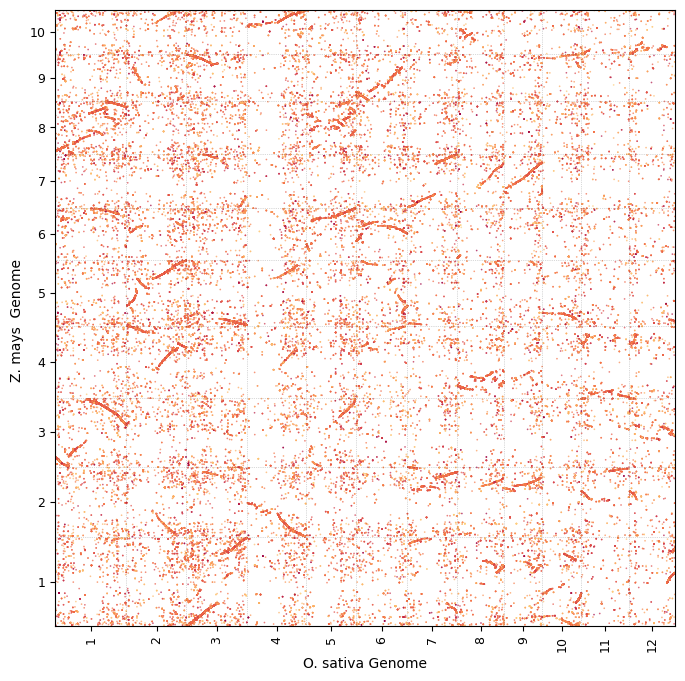

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import re

rice_nuclear_chrs = [str(i) for i in range(1, 13)] 
maize_nuclear_chrs = [str(i) for i in range(1, 11)] 

df_rice_nuc = df_rice_gene[df_rice_gene['seqid'].astype(str).isin(rice_nuclear_chrs)].copy()
df_maize_nuc = df_maize_gene[df_maize_gene['seqid'].astype(str).isin(maize_nuclear_chrs)].copy()

final_df_nuc = final_df_gene[
    (final_df_gene['chr1'].astype(str).isin(rice_nuclear_chrs)) & 
    (final_df_gene['chr2'].astype(str).isin(maize_nuclear_chrs))
].copy()

def get_layout(df, seqid_col, pos_col):

    def sort_key(x):
        import re
        nums = re.findall(r'\d+', str(x))
        return int(nums[0]) if nums else 999
        
    chr_sizes = df.groupby(seqid_col)[pos_col].max()
    sorted_chroms = sorted(chr_sizes.index.tolist(), key=sort_key)
    
    offset_map = {}
    curr = 0
    ticks = []
    bounds = []
    
    for chrom in sorted_chroms:
        size = chr_sizes[chrom]
        offset_map[chrom] = curr
        bounds.append(curr + size)
        ticks.append((chrom, curr + size/2))
        curr += size + (size * 0.01) # 1% padding
        
    return offset_map, bounds, ticks, curr

off1, bounds1, ticks1, len1 = get_layout(df_rice_nuc, 'seqid', 'start')
off2, bounds2, ticks2, len2 = get_layout(df_maize_nuc, 'seqid', 'start')

final_df_nuc['plot_x'] = final_df_nuc.apply(lambda row: row['pos1'] + off1.get(row['chr1'], 0), axis=1)
final_df_nuc['plot_y'] = final_df_nuc.apply(lambda row: row['pos2'] + off2.get(row['chr2'], 0), axis=1)

plt.figure(figsize=(8, 8))
ax = plt.gca()
cmap = plt.cm.get_cmap('Spectral_r')
sc = ax.scatter(final_df_nuc['plot_x'], final_df_nuc['plot_y'], 
                c=final_df_nuc['pident'], 
                cmap='Spectral_r', 
                vmin=20, vmax=100, 
                s=1.5, alpha=0.7, edgecolors='none')
for b in bounds1: ax.axvline(x=b, color='k', ls=':', lw=0.5, alpha=0.3)
for b in bounds2: ax.axhline(y=b, color='k', ls=':', lw=0.5, alpha=0.3)
ax.set_xticks([t[1] for t in ticks1])
ax.set_xticklabels([str(t[0]).replace('rice_', '').replace('Chr','') for t in ticks1], rotation=90, fontsize=9)

ax.set_yticks([t[1] for t in ticks2])
ax.set_yticklabels([str(t[0]).replace('maize_', '').replace('Chr','') for t in ticks2], fontsize=9)

ax.set_xlabel("O. sativa Genome")
ax.set_ylabel("Z. mays  Genome ")

ax.set_xlim(0, len1)
ax.set_ylim(0, len2)

# 保存图片
plt.savefig('gene1.png', dpi=600) 
plt.savefig('gene1.pdf', dpi=600)
plt.savefig('gene1.svg', dpi=600)
plt.show()

In [10]:
final_df_nuc
df_sorted = final_df_nuc.sort_values(by=['bitscore', 'pident', 'evalue'], 
                           ascending=[False, False, True])
df_sorted 

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,ID_x,chr1,pos1,ID_y,chr2,pos2,plot_x,plot_y
59412,Os09t0247700-01,Zm00001eb308350_T002,82.409,15218,2490,144,59,15183,48,15171,0.000000,13099.0,Os09t0247700-01,9,3586851,Zm00001eb308350_T002,7,74443495,2.764600e+08,1.536305e+09
59413,Os09t0247700-01,Zm00001eb308350_T001,82.499,14668,2381,142,59,14635,48,14620,0.000000,12694.0,Os09t0247700-01,9,3586851,Zm00001eb308350_T001,7,74443395,2.764600e+08,1.536305e+09
74357,Os12t0428600-01,Zm00001eb409870_T001,83.448,11008,1666,88,3,10938,6,10929,0.000000,10091.0,Os12t0428600-01,12,13686984,Zm00001eb409870_T001,10,20959139,3.624614e+08,2.019060e+09
74358,Os12t0428600-01,Zm00001eb133420_T001,83.040,11014,1667,109,6,10938,3,10896,0.000000,9804.0,Os12t0428600-01,12,13686984,Zm00001eb133420_T001,3,98733038,3.624614e+08,6.560497e+08
74359,Os12t0428600-01,Zm00001eb133420_T002,82.980,10758,1633,107,262,10938,202,10842,0.000000,9540.0,Os12t0428600-01,12,13686984,Zm00001eb133420_T002,3,98733038,3.624614e+08,6.560497e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91588,Os11t0421800-01,Zm00001eb408440_T003,91.892,37,3,0,15,51,12,48,0.000005,52.8,Os11t0421800-01,11,13200164,Zm00001eb408440_T003,10,11625491,3.326677e+08,2.009726e+09
19912,Os08t0514033-00,Zm00001eb124850_T001,91.892,37,3,0,577,613,772,808,0.000007,52.8,Os08t0514033-00,8,25494552,Zm00001eb124850_T001,3,20003508,2.696827e+08,5.773201e+08
24197,Os12t0548501-01,Zm00001eb230690_T001,84.615,52,8,0,30,81,27,78,0.000003,52.8,Os12t0548501-01,12,22197957,Zm00001eb230690_T001,5,74411482,3.709724e+08,1.124696e+09
24198,Os12t0548501-01,Zm00001eb230670_T001,84.615,52,8,0,30,81,27,78,0.000003,52.8,Os12t0548501-01,12,22197957,Zm00001eb230670_T001,5,74258973,3.709724e+08,1.124543e+09


>>> 筛选出的最佳同源对:
    水稻: Os09t0247700-01
    玉米: Zm00001eb308350_T002
----------------------------------------
>>> 正在提取序列...
>>> 正在进行比对计算...
【总体结果】
每核苷酸平均差异 (Mean Diff per nt): 0.16194
>>> 正在绘制滑窗分析图...
>>> 图片已保存为: divergence_plot_Os09t0247700-01_Zm00001eb308350_T002.png


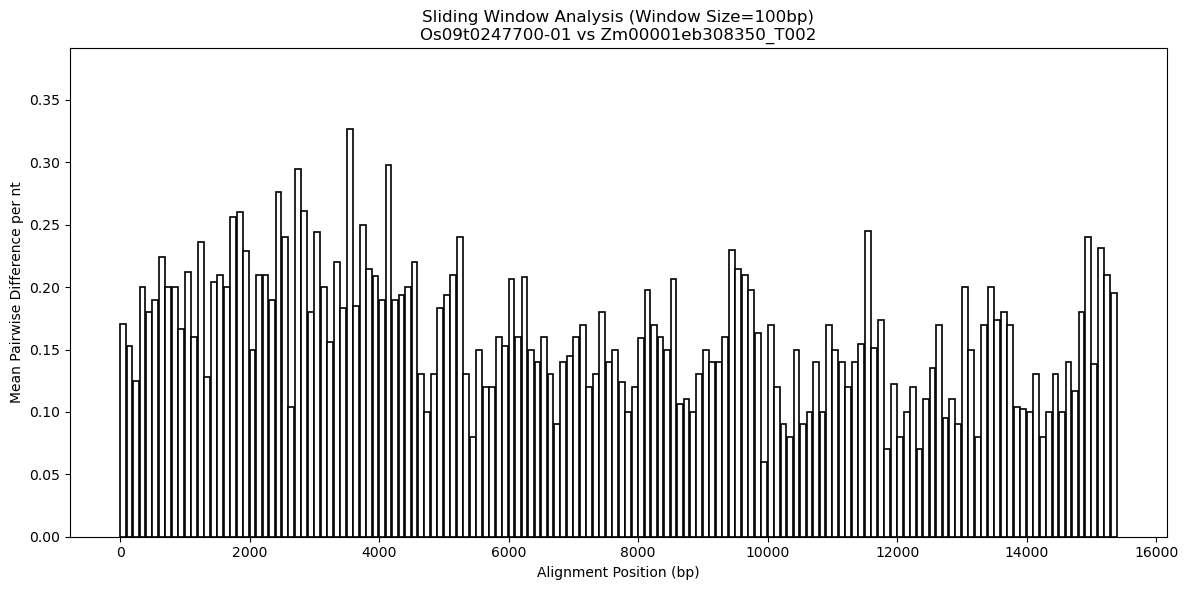

In [11]:
import pandas as pd
import io 
from Bio import SeqIO, Align
import matplotlib.pyplot as plt # 引入绘图库

best_pair = final_df_nuc.sort_values(by=['bitscore', 'pident'], ascending=[False, False]).iloc[0]

def safe_get_id(row, col_name):
    val = row[col_name]
    if isinstance(val, pd.Series) or isinstance(val, list):
        val = val.iloc[0] 
    return str(val).strip() 

rice_id = safe_get_id(best_pair, 'qseqid')
maize_id = safe_get_id(best_pair, 'sseqid')

print(f">>> 筛选出的最佳同源对:")
print(f"    水稻: {rice_id}")
print(f"    玉米: {maize_id}")
print("-" * 40)

rice_fasta_file = "/data/user_home/2023122004/FFTransformer/data/Oryza/genome/Oryza_sativa.IRGSP-1.0.cds.all.fa"
maize_fasta_file = "/data/user_home/2023122004/FFTransformer/data/maize/genome/Zea_mays.Zm-B73-REFERENCE-NAM-5.0.cds.all.fa"

def get_sequence_by_id(fasta_file, target_id):
    try:
        record_dict = SeqIO.index(fasta_file, "fasta")
        if target_id in record_dict:
            return str(record_dict[target_id].seq)
        else:
            print(f"错误: 在 {fasta_file} 中找不到 ID: {target_id}")
            return None
    except FileNotFoundError:
        print(f"错误: 找不到文件 {fasta_file}")
        return None

print(">>> 正在提取序列...")
rice_seq = get_sequence_by_id(rice_fasta_file, rice_id)
maize_seq = get_sequence_by_id(maize_fasta_file, maize_id)

if not rice_seq or not maize_seq:
    exit()

# ==========================================
# 2. 序列比对 
# ==========================================

def calculate_pairwise_diff_and_get_seqs(seq1, seq2):
    """
    执行全局比对，返回：
    1. 总体平均差异
    2. 有效位点数
    3. 错配数
    4. 对齐后的序列字符串 (seq1_aln, seq2_aln) -> 用于后续滑窗分析
    """
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'
    aligner.match_score = 1.0
    aligner.mismatch_score = -2.0
    aligner.open_gap_score = -2.5
    aligner.extend_gap_score = -1.0
    
    alignments = aligner.align(seq1, seq2)
    try:
        best_aln = alignments[0]
    except IndexError:
        return 0, 0, 0, "", ""

    aln_fasta_str = format(best_aln, "fasta")
    with io.StringIO(aln_fasta_str) as handle:
        records = list(SeqIO.parse(handle, "fasta"))
        
    s1_final = str(records[0].seq)
    s2_final = str(records[1].seq)

    mismatches = 0
    valid_sites = 0
    alignment_len = len(s1_final)
    
    for i in range(alignment_len):
        b1 = s1_final[i].upper()
        b2 = s2_final[i].upper()
        if b1 not in ['-', 'N'] and b2 not in ['-', 'N']:
            valid_sites += 1
            if b1 != b2:
                mismatches += 1
                
    mean_diff = mismatches / valid_sites if valid_sites > 0 else 0
    return mean_diff, valid_sites, mismatches, s1_final, s2_final

diff, sites, mis, aln_seq1, aln_seq2 = calculate_pairwise_diff_and_get_seqs(rice_seq, maize_seq)

print("=" * 40)
print(f"【总体结果】")
print(f"每核苷酸平均差异 (Mean Diff per nt): {diff:.5f}")
print("=" * 40)

def sliding_window_and_plot(seq1_aln, seq2_aln, window_size=100):
    """
    每 100bp 切片计算差异度并绘图
    """
    x_positions = []
    y_diff_rates = []
    
    total_len = len(seq1_aln)

    for i in range(0, total_len, window_size):

        sub_s1 = seq1_aln[i : i + window_size]
        sub_s2 = seq2_aln[i : i + window_size]
        
        local_mismatches = 0
        local_valid = 0
        
        for b1, b2 in zip(sub_s1, sub_s2):
            b1, b2 = b1.upper(), b2.upper()
            if b1 not in ['-', 'N'] and b2 not in ['-', 'N']:
                local_valid += 1
                if b1 != b2:
                    local_mismatches += 1

        rate = local_mismatches / local_valid if local_valid > 0 else 0.0
        
        x_positions.append(i)
        y_diff_rates.append(rate)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(x_positions, y_diff_rates, width=window_size*0.9, align='edge',
                   color='white', edgecolor='black', linewidth=1.2)
    
            
    plt.title(f"Sliding Window Analysis (Window Size={window_size}bp)\n{rice_id} vs {maize_id}")
    plt.xlabel("Alignment Position (bp)")
    plt.ylabel("Mean Pairwise Difference per nt")
    plt.ylim(0, max(y_diff_rates) * 1.2 if y_diff_rates else 0.5)
    
    plt.tight_layout()
    output_filename = f"divergence_plot_{rice_id}_{maize_id}.png"
    plt.savefig(output_filename, dpi=300)
    print(f">>> 图片已保存为: {output_filename}")
    plt.show() 

print(">>> 正在绘制滑窗分析图...")
sliding_window_and_plot(aln_seq1, aln_seq2, window_size=100)

In [12]:
df = final_df
cols_to_numeric = ['pos1', 'pos2', 'pident', 'bitscore', 'evalue']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

filtered_df = df[
    (df['pident'] >= 60) & 
    (df['evalue'] < 1e-10)
].copy()

filtered_df = filtered_df.sort_values(by=['chr1', 'pos1'])
MAX_GAP = 50000 

# 计算相邻 sORF 在 chr1 上的距离
# 这里的逻辑是：如果 (当前pos - 上一个pos) > MAX_GAP，则 group_id + 1
filtered_df['diff'] = filtered_df['pos1'].diff().fillna(0)
filtered_df['is_new_block'] = (filtered_df['diff'] > MAX_GAP) | (filtered_df['chr1'] != filtered_df['chr1'].shift())
filtered_df['block_id'] = filtered_df['is_new_block'].cumsum()
# 聚合统计
block_stats = filtered_df.groupby('block_id').agg({
    'chr1': 'first',              # 该区块所在的染色体
    'pos1': ['min', 'max'],       # 区间范围 (Start, End)
    'qseqid': 'count',            # sORF 的数量 (Count)
    'bitscore': 'sum',            # 总比对得分 (Total Score)
    'pident': 'mean',             # 平均相似度
    'chr2': 'first',              # 对应的目标染色体 (大致)
    'pos2': ['min', 'max']        # 目标染色体范围
}).reset_index()

block_stats.columns = ['block_id', 'chr1', 'start', 'end', 'sorf_count', 'total_bitscore', 'avg_pident', 'chr2', 'subj_start', 'subj_end']

# 计算区间长度
block_stats['region_length'] = block_stats['end'] - block_stats['start']

# 4. 筛选“高比对”区间
# 比如：找出包含至少 5 个 sORF，且总分最高的区间
top_blocks = block_stats[block_stats['sorf_count'] >= 5].sort_values(by='total_bitscore', ascending=False)

# 聚合统计
block_stats = filtered_df.groupby('block_id').agg({
    'chr1': 'first',              # 该区块所在的染色体
    'pos1': ['min', 'max'],       # 区间范围 (Start, End)
    'qseqid': 'count',            # sORF 的数量 (Count)
    'bitscore': 'sum',            # 总比对得分 (Total Score)
    'pident': 'mean',             # 平均相似度
    'chr2': 'first',              # 对应的目标染色体 (大致)
    'pos2': ['min', 'max']        # 目标染色体范围
}).reset_index()

block_stats.columns = ['block_id', 'chr1', 'start', 'end', 'sorf_count', 'total_bitscore', 'avg_pident', 'chr2', 'subj_start', 'subj_end']
block_stats['region_length'] = block_stats['end'] - block_stats['start']
top_blocks = block_stats[block_stats['sorf_count'] >= 5].sort_values(by='total_bitscore', ascending=False)
print(top_blocks.head(5))

     block_id chr1     start       end  sorf_count  total_bitscore  \
652       653    6   2900189   2942079          42          3227.8   
328       329    2  30328411  30468072          42          2775.3   
485       486    3  35180218  35182199          33          2437.4   
119       120   10  20575002  20676192          34          2302.5   
770       771    7  23245264  23246718          25          2099.6   

     avg_pident chr2  subj_start   subj_end  region_length  
652   74.850571    6    20076597  202796294          41890  
328   80.493905    5    11997909  219305523         139661  
485   91.359545    1    11621620  303183533           1981  
119   67.117324    8     9587105  299091829         101190  
770   80.683040    2   139522992  237440436           1454  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from Bio import SeqIO

final_merge = final_df.merge(df_rice[['ID', 'Region_Category']], left_on='qseqid', right_on='ID', how='left')
final_merge
print("当前的 sORF 分类统计:")
print(final_merge['Region_Category'].value_counts())

当前的 sORF 分类统计:
Region_Category
CDS           11139
Intergenic     1539
uoORF           935
doORF           815
3UTR            742
5UTR            113
lncRNA           58
Name: count, dtype: int64


In [14]:
final_merge
df_annotation=pd.read_csv('/data/user_home/2023122004/FFTransformer/protein/predict_sorf/maize/startCDS_with_Position.csv')
df_annotation

,ID,seqid,start,end,strand,Length_bp,Region_Category,CDS_Start_Status,Ref_Feature_ID,Ref_Feature_Coords,DNA_Sequence,attributes,CDS_Distance_bp,CDS_Relative_Pos,CDS_Relative_Pos_Formatted
0,sorf_1_1,1,35062,35310,+,249,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:34722-35318(+),ATGGCGTCCGCGAGCTGGACGAGCTTGGCCTCTGGGCGTCGTGGAG...,ID=sorf_1_1;len=249;conf=1.00;start_codon=ATG,340.0,0.184582,0.1846
1,sorf_1_2,1,36108,36140,+,33,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:36037-36174(+),GATGATGACATACTTATCAATACCTGCAGATGA,ID=sorf_1_2;len=33;conf=1.00;start_codon=GAT,668.0,0.362649,0.3626
2,sorf_1_3,1,36272,36379,+,108,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:36259-36504(+),ATGGTGGTGTTAGCATGTTGGGACATGGAGATGTGTCATTTCCTTA...,ID=sorf_1_3;len=108;conf=1.00;start_codon=ATG,748.0,0.406080,0.4061
3,sorf_1_4,1,36916,36981,+,66,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:36822-37004(+),ATGTTCTGGGCATCAGTAAAAAAATGGTGGTTCCAGTCATTACATC...,ID=sorf_1_4;len=66;conf=1.00;start_codon=ATG,1189.0,0.645494,0.6455
4,sorf_1_5,1,37451,37486,+,36,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:37416-37633(+),GAAAACAACAGGAAAAATTCTGTGTCGTTCGCCTGA,ID=sorf_1_5;len=36;conf=1.00;start_codon=GAA,1313.0,0.712812,0.7128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64812,sorf_9_11504,9,162504130,162504171,+,42,Intergenic,NaN,No_Match,-,ATGGCAAGCATTTGTGGGTGTTGGTGCTCGAAGGATTCCTAG,ID=sorf_9_11504;len=42;conf=1.00;start_codon=ATG,NaN,NaN,NaN
64813,sorf_9_11505,9,162505005,162505055,+,51,CDS,Internal_CDS,CDS:Zm00001eb404700_P002,9:162504920-162505081(+),ATGGATCTGTTGACGAGGGTGTGGCTTATTTTGTTGAGTGGGCTAT...,ID=sorf_9_11505;len=51;conf=1.00;start_codon=ATG,853.0,0.585048,0.5850
64814,sorf_9_11506,9,162505216,162505248,+,33,CDS,Internal_CDS,CDS:Zm00001eb404700_P003,9:162505175-162505306(+),ATGTGGAATCATCAAAGTGATTGCAAGAATTGA,ID=sorf_9_11506;len=33;conf=1.00;start_codon=ATG,971.0,0.904097,0.9041
64815,sorf_9_11507,9,162510493,162510552,+,60,doORF,Internal_CDS,CDS:Zm00001eb404700_P001,9:162510482-162510633(+),ATGGTACCTCTCGTAATTCATCCCGTTATGGAGATTTTGATGAAGA...,ID=sorf_9_11507;len=60;conf=1.00;start_codon=ATG,1051.0,0.719370,0.7194


In [15]:
df_synteny= final_merge.copy()

df_annotation['ID'] = df_annotation['ID'].astype(str)
df_annotation['ID'] = df_annotation['ID'].astype(str).str.strip()
if not df_annotation['ID'].iloc[0].startswith('maize_'):
    df_annotation['ID'] = 'maize_' + df_annotation['ID']
df_annotation


,ID,seqid,start,end,strand,Length_bp,Region_Category,CDS_Start_Status,Ref_Feature_ID,Ref_Feature_Coords,DNA_Sequence,attributes,CDS_Distance_bp,CDS_Relative_Pos,CDS_Relative_Pos_Formatted
0,maize_sorf_1_1,1,35062,35310,+,249,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:34722-35318(+),ATGGCGTCCGCGAGCTGGACGAGCTTGGCCTCTGGGCGTCGTGGAG...,ID=sorf_1_1;len=249;conf=1.00;start_codon=ATG,340.0,0.184582,0.1846
1,maize_sorf_1_2,1,36108,36140,+,33,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:36037-36174(+),GATGATGACATACTTATCAATACCTGCAGATGA,ID=sorf_1_2;len=33;conf=1.00;start_codon=GAT,668.0,0.362649,0.3626
2,maize_sorf_1_3,1,36272,36379,+,108,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:36259-36504(+),ATGGTGGTGTTAGCATGTTGGGACATGGAGATGTGTCATTTCCTTA...,ID=sorf_1_3;len=108;conf=1.00;start_codon=ATG,748.0,0.406080,0.4061
3,maize_sorf_1_4,1,36916,36981,+,66,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:36822-37004(+),ATGTTCTGGGCATCAGTAAAAAAATGGTGGTTCCAGTCATTACATC...,ID=sorf_1_4;len=66;conf=1.00;start_codon=ATG,1189.0,0.645494,0.6455
4,maize_sorf_1_5,1,37451,37486,+,36,CDS,Internal_CDS,CDS:Zm00001eb000010_P001,1:37416-37633(+),GAAAACAACAGGAAAAATTCTGTGTCGTTCGCCTGA,ID=sorf_1_5;len=36;conf=1.00;start_codon=GAA,1313.0,0.712812,0.7128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64812,maize_sorf_9_11504,9,162504130,162504171,+,42,Intergenic,NaN,No_Match,-,ATGGCAAGCATTTGTGGGTGTTGGTGCTCGAAGGATTCCTAG,ID=sorf_9_11504;len=42;conf=1.00;start_codon=ATG,NaN,NaN,NaN
64813,maize_sorf_9_11505,9,162505005,162505055,+,51,CDS,Internal_CDS,CDS:Zm00001eb404700_P002,9:162504920-162505081(+),ATGGATCTGTTGACGAGGGTGTGGCTTATTTTGTTGAGTGGGCTAT...,ID=sorf_9_11505;len=51;conf=1.00;start_codon=ATG,853.0,0.585048,0.5850
64814,maize_sorf_9_11506,9,162505216,162505248,+,33,CDS,Internal_CDS,CDS:Zm00001eb404700_P003,9:162505175-162505306(+),ATGTGGAATCATCAAAGTGATTGCAAGAATTGA,ID=sorf_9_11506;len=33;conf=1.00;start_codon=ATG,971.0,0.904097,0.9041
64815,maize_sorf_9_11507,9,162510493,162510552,+,60,doORF,Internal_CDS,CDS:Zm00001eb404700_P001,9:162510482-162510633(+),ATGGTACCTCTCGTAATTCATCCCGTTATGGAGATTTTGATGAAGA...,ID=sorf_9_11507;len=60;conf=1.00;start_codon=ATG,1051.0,0.719370,0.7194


In [16]:
merged_df = pd.merge(
    df_synteny, 
    df_annotation, 
    left_on='sseqid', 
    right_on='ID', 
    how='inner',
    suffixes=('_syn', '_annot') 
)
merged_df

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,...,Length_bp,Region_Category_annot,CDS_Start_Status,Ref_Feature_ID,Ref_Feature_Coords,DNA_Sequence,attributes,CDS_Distance_bp,CDS_Relative_Pos,CDS_Relative_Pos_Formatted
0,rice_sorf_1_12,maize_sorf_10_7725,46.429,56,30,0,44,211,5,172,...,279,CDS,Internal_CDS,CDS:Zm00001eb429220_P001,10:140750266-140750614(+),GAACACACTGAACATCCAGATCCAAGGGCACAAGATGACGCTGGTC...,ID=sorf_10_7725;len=279;conf=1.00;start_codon=GAA,659.0,0.403058,0.4031
1,rice_sorf_1_12,maize_sorf_10_7725,54.054,37,17,0,168,58,129,19,...,279,CDS,Internal_CDS,CDS:Zm00001eb429220_P001,10:140750266-140750614(+),GAACACACTGAACATCCAGATCCAAGGGCACAAGATGACGCTGGTC...,ID=sorf_10_7725;len=279;conf=1.00;start_codon=GAA,659.0,0.403058,0.4031
2,rice_sorf_1_15,maize_sorf_8_668,96.875,32,1,0,3,98,3,98,...,99,CDS,Internal_CDS,CDS:Zm00001eb334030_P001,8:6999204-6999904(+),ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,ID=sorf_8_668;len=99;conf=1.00;start_codon=ATG,778.0,0.484735,0.4847
3,rice_sorf_1_15,maize_sorf_8_668,90.625,32,3,0,97,2,97,2,...,99,CDS,Internal_CDS,CDS:Zm00001eb334030_P001,8:6999204-6999904(+),ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,ID=sorf_8_668;len=99;conf=1.00;start_codon=ATG,778.0,0.484735,0.4847
4,rice_sorf_1_15,maize_sorf_8_668,87.500,32,4,0,98,3,98,3,...,99,CDS,Internal_CDS,CDS:Zm00001eb334030_P001,8:6999204-6999904(+),ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,ID=sorf_8_668;len=99;conf=1.00;start_codon=ATG,778.0,0.484735,0.4847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15336,rice_sorf_9_6291,maize_sorf_3_15036,68.000,25,8,0,2,76,26,100,...,102,CDS,Internal_CDS,CDS:Zm00001eb162400_P001,3:232352843-232352998(+),GATTTGGGGTTGTATGGTGGTCATTTGCTACAGTTCTTACACCCCT...,ID=sorf_3_15036;len=102;conf=1.00;start_codon=GAT,823.0,0.446070,0.4461
15337,rice_sorf_9_6291,maize_sorf_3_15036,80.000,25,5,0,76,2,100,26,...,102,CDS,Internal_CDS,CDS:Zm00001eb162400_P001,3:232352843-232352998(+),GATTTGGGGTTGTATGGTGGTCATTTGCTACAGTTCTTACACCCCT...,ID=sorf_3_15036;len=102;conf=1.00;start_codon=GAT,823.0,0.446070,0.4461
15338,rice_sorf_9_6291,maize_sorf_3_15036,66.667,24,8,0,77,6,101,30,...,102,CDS,Internal_CDS,CDS:Zm00001eb162400_P001,3:232352843-232352998(+),GATTTGGGGTTGTATGGTGGTCATTTGCTACAGTTCTTACACCCCT...,ID=sorf_3_15036;len=102;conf=1.00;start_codon=GAT,823.0,0.446070,0.4461
15339,rice_sorf_9_6343,maize_sorf_1_13345,58.333,36,15,0,2,109,11,118,...,156,uoORF,Internal_CDS,CDS:Zm00001eb041410_P003,1:218053550-218053802(+),GTGCCAGAGGTGGAAGAGCAAAGGCGTGAACATAAAGTACGAGGTG...,ID=sorf_1_13345;len=156;conf=1.00;start_codon=GTG,494.0,0.289397,0.2894


In [17]:
def load_gene_coordinates(gff_file):
    cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
    df = pd.read_csv(gff_file, sep='\t', comment='#', header=None, names=cols)
    genes = df[df['type'] == 'gene'].copy()
    genes['Gene_ID'] = genes['attributes'].apply(lambda x: re.search(r'ID=([^;]+)', x).group(1))
    
    return genes.set_index('Gene_ID')[['start', 'end', 'strand', 'seqid']]

gff_genes = load_gene_coordinates("/data/user_home/2023122004/FFTransformer/data/maize/gff3/ZmB73.gff3")
gff_genes = gff_genes.reset_index() 
gff_genes 

,Gene_ID,start,end,strand,seqid
0,gene:Zm00001eb000010,34617,40204,+,1
1,gene:Zm00001eb000020,41214,46762,-,1
2,gene:Zm00001eb000050,108554,114382,-,1
3,gene:Zm00001eb000060,188559,189581,-,1
4,gene:Zm00001eb000070,190192,198832,-,1
...,...,...,...,...,...
39030,gene:Zm00001eb404690,162278225,162280767,-,9
39031,gene:Zm00001eb404700,162498899,162511418,+,9
39032,gene:Zm00001eb404710,162552801,162575880,-,9
39033,gene:Zm00001eb404720,162707413,162742092,-,9


In [18]:
BLAST_PIDENT_THRESHOLD = 70.0   # 相似度 > 70%
BLAST_EVALUE_THRESHOLD = 1e-6  # E-value < 1e-10 (非常显著)
high_quality_hits = merged_df[
    (merged_df['pident'] >= BLAST_PIDENT_THRESHOLD) &
    (merged_df['evalue'] < BLAST_EVALUE_THRESHOLD)
].copy()

high_quality_hits_filter = high_quality_hits[['qseqid','sseqid','pident','Ref_Feature_ID',	'Ref_Feature_Coords','DNA_Sequence'	]]
high_quality_hits_filter = high_quality_hits_filter .rename(
    columns={"DNA_Sequence": "maize_DNA"}
)


cds_coords = high_quality_hits_filter["Ref_Feature_Coords"].str.extract(
    r'(?P<chr>\d+):(?P<cds_start>\d+)-(?P<cds_end>\d+)\((?P<strand>[+-])\)'
)

high_quality_hits_filter= pd.concat([high_quality_hits_filter, cds_coords], axis=1)
high_quality_hits_filter[["cds_start", "cds_end"]] = (
    high_quality_hits_filter[["cds_start", "cds_end"]]
    .apply(pd.to_numeric, errors="coerce")
)

# high_quality_hits_filter= high_quality_hits_filter.drop(
#     columns=["Ref_Feature_ID", "Ref_Feature_Coords"],
#     errors="ignore"
# )
high_quality_hits_filter
gff_genes['mazie_gene_ID'] = gff_genes['Gene_ID'].astype(str).str.replace('gene:', '', regex=False)
gff_dict = gff_genes.set_index('mazie_gene_ID')[['start', 'end', 'strand']].to_dict('index')

def clean_sorf_id(ref_id):
    s = str(ref_id).replace('CDS:', '')
    base_id = s.split('_')[0]
    return base_id
high_quality_hits_filter['mazie_gene_ID'] = high_quality_hits_filter['Ref_Feature_ID'].apply(clean_sorf_id)
high_quality_hits_filter
gene_coords_map = gff_genes[['mazie_gene_ID', 'start', 'end', 'strand']].rename(columns={
    'start': 'maiza_gene_start',
    'end':   'maiza_gene_end',
    'strand': 'maiza_gene_strand'
})
high_quality_hits_filter = pd.merge(
    high_quality_hits_filter, 
    gene_coords_map, 
    on='mazie_gene_ID', 
    how='left'
)
high_quality_hits_filter1=high_quality_hits_filter[['qseqid','sseqid','pident','maize_DNA','mazie_gene_ID','maiza_gene_start','maiza_gene_end','maiza_gene_strand']]
high_quality_hits_filter1

,qseqid,sseqid,pident,maize_DNA,mazie_gene_ID,maiza_gene_start,maiza_gene_end,maiza_gene_strand
0,rice_sorf_1_15,maize_sorf_8_668,96.875,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+
1,rice_sorf_1_15,maize_sorf_8_668,90.625,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+
2,rice_sorf_1_15,maize_sorf_8_668,87.500,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+
3,rice_sorf_1_15,maize_sorf_8_668,77.419,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+
4,rice_sorf_1_15,maize_sorf_8_668,83.871,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+
...,...,...,...,...,...,...,...,...
7672,rice_sorf_9_6273,maize_sorf_2_7181,77.419,ATGAGGAAGAGGTTCATATTGCAGTCGGCAAGAACTCAAGAAAGGA...,No,NaN,NaN,NaN
7673,rice_sorf_9_6273,maize_sorf_2_7181,71.875,ATGAGGAAGAGGTTCATATTGCAGTCGGCAAGAACTCAAGAAAGGA...,No,NaN,NaN,NaN
7674,rice_sorf_9_6273,maize_sorf_2_7181,70.968,ATGAGGAAGAGGTTCATATTGCAGTCGGCAAGAACTCAAGAAAGGA...,No,NaN,NaN,NaN
7675,rice_sorf_9_6291,maize_sorf_3_15036,92.000,GATTTGGGGTTGTATGGTGGTCATTTGCTACAGTTCTTACACCCCT...,Zm00001eb162400,232351114.0,232356036.0,+


In [19]:
df_rice=pd.read_csv('/data/user_home/2023122004/FFTransformer/protein/predict_sorf/rice/Pann_Annotation_Detailed.csv')
df_rice
df_rice['ID'] = df_rice['ID'].astype(str)


# df_maize = df_maize.copy()
df_rice['ID'] = df_rice['ID'].astype(str).str.strip()
if not df_rice['ID'].iloc[0].startswith('maize_'):
    df_rice['ID'] = 'rice_' +df_rice['ID']
df_rice=df_rice[['ID','DNA_Sequence','Ref_Feature_ID']]


gff_rice= load_gene_coordinates("/data/user_home/2023122004/FFTransformer/data/Oryza/genome/Oryza_sativa.IRGSP-1.0.62.chr.gff3")
gff_rice= gff_rice.reset_index() 
gff_rice
gff_rice['rice_gene_ID'] = gff_rice['Gene_ID'].astype(str).str.replace('gene:', '', regex=False)
gff_rice["rice_gene_ID"] = gff_rice["rice_gene_ID"].str.replace(
    "g", "t", n=1
)
gff_rice

high_quality_hits_filter2 = high_quality_hits_filter1.merge(
    df_rice,
    left_on="qseqid",
    right_on="ID",
    how="left"
)
high_quality_hits_filter2 = high_quality_hits_filter2.drop(columns=["ID"])
high_quality_hits_filter2 

high_quality_hits_filter2['Ref_Feature_ID'] = high_quality_hits_filter2['Ref_Feature_ID'].apply(clean_sorf_id)
high_quality_hits_filter2= high_quality_hits_filter2.rename(
    columns={"DNA_Sequence": "rice_DNA"}
)
high_quality_hits_filter2= high_quality_hits_filter2.rename(
    columns={"Ref_Feature_ID": "rice_gene_ID"}
)
high_quality_hits_filter2["rice_gene_ID"] = (
    high_quality_hits_filter2["rice_gene_ID"]
    .astype(str)
    .str.split("-", n=1)
    .str[0]
)
high_quality_hits_filter2


/tmp/ipykernel_35132/88206523.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(gff_file, sep='\t', comment='#', header=None, names=cols)


,qseqid,sseqid,pident,maize_DNA,mazie_gene_ID,maiza_gene_start,maiza_gene_end,maiza_gene_strand,rice_DNA,rice_gene_ID
0,rice_sorf_1_15,maize_sorf_8_668,96.875,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500
1,rice_sorf_1_15,maize_sorf_8_668,90.625,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500
2,rice_sorf_1_15,maize_sorf_8_668,87.500,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500
3,rice_sorf_1_15,maize_sorf_8_668,77.419,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500
4,rice_sorf_1_15,maize_sorf_8_668,83.871,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500
...,...,...,...,...,...,...,...,...,...,...
7672,rice_sorf_9_6273,maize_sorf_2_7181,77.419,ATGAGGAAGAGGTTCATATTGCAGTCGGCAAGAACTCAAGAAAGGA...,No,NaN,NaN,NaN,ATGAGGAAGAGATTCATATTGCGGTTGGGAAGAACTTCAGAAAGGA...,No
7673,rice_sorf_9_6273,maize_sorf_2_7181,71.875,ATGAGGAAGAGGTTCATATTGCAGTCGGCAAGAACTCAAGAAAGGA...,No,NaN,NaN,NaN,ATGAGGAAGAGATTCATATTGCGGTTGGGAAGAACTTCAGAAAGGA...,No
7674,rice_sorf_9_6273,maize_sorf_2_7181,70.968,ATGAGGAAGAGGTTCATATTGCAGTCGGCAAGAACTCAAGAAAGGA...,No,NaN,NaN,NaN,ATGAGGAAGAGATTCATATTGCGGTTGGGAAGAACTTCAGAAAGGA...,No
7675,rice_sorf_9_6291,maize_sorf_3_15036,92.000,GATTTGGGGTTGTATGGTGGTCATTTGCTACAGTTCTTACACCCCT...,Zm00001eb162400,232351114.0,232356036.0,+,TTGCGACAGTTCTTACACCCCTTGCTGCAAAGATTGGACTTCCTTT...,Os09t0570400


In [20]:
rice_coords_map = gff_rice[['rice_gene_ID', 'start', 'end', 'strand']].rename(columns={
    'start': 'rice_gene_start',
    'end':   'rice_gene_end',
    'strand': 'rice_gene_strand'
})
rice_coords_map
high_quality_hits_filter3 = pd.merge(
    high_quality_hits_filter2, 
    rice_coords_map, 
    on='rice_gene_ID', 
    how='left'
)
high_quality_hits_filter3

,qseqid,sseqid,pident,maize_DNA,mazie_gene_ID,maiza_gene_start,maiza_gene_end,maiza_gene_strand,rice_DNA,rice_gene_ID,rice_gene_start,rice_gene_end,rice_gene_strand
0,rice_sorf_1_15,maize_sorf_8_668,96.875,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500,16399.0,20144.0,+
1,rice_sorf_1_15,maize_sorf_8_668,90.625,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500,16399.0,20144.0,+
2,rice_sorf_1_15,maize_sorf_8_668,87.500,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500,16399.0,20144.0,+
3,rice_sorf_1_15,maize_sorf_8_668,77.419,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500,16399.0,20144.0,+
4,rice_sorf_1_15,maize_sorf_8_668,83.871,ATGGCTGCCGAATCCCTCCAAGAGACCACTATGTATCCTGGCAGTT...,Zm00001eb334030,6995879.0,7002257.0,+,ATGGCTGCAGAATCCCGCCAAGAGACCACTACGTATCCTGGCAATT...,Os01t0100500,16399.0,20144.0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7672,rice_sorf_9_6273,maize_sorf_2_7181,77.419,ATGAGGAAGAGGTTCATATTGCAGTCGGCAAGAACTCAAGAAAGGA...,No,NaN,NaN,NaN,ATGAGGAAGAGATTCATATTGCGGTTGGGAAGAACTTCAGAAAGGA...,No,NaN,NaN,NaN
7673,rice_sorf_9_6273,maize_sorf_2_7181,71.875,ATGAGGAAGAGGTTCATATTGCAGTCGGCAAGAACTCAAGAAAGGA...,No,NaN,NaN,NaN,ATGAGGAAGAGATTCATATTGCGGTTGGGAAGAACTTCAGAAAGGA...,No,NaN,NaN,NaN
7674,rice_sorf_9_6273,maize_sorf_2_7181,70.968,ATGAGGAAGAGGTTCATATTGCAGTCGGCAAGAACTCAAGAAAGGA...,No,NaN,NaN,NaN,ATGAGGAAGAGATTCATATTGCGGTTGGGAAGAACTTCAGAAAGGA...,No,NaN,NaN,NaN
7675,rice_sorf_9_6291,maize_sorf_3_15036,92.000,GATTTGGGGTTGTATGGTGGTCATTTGCTACAGTTCTTACACCCCT...,Zm00001eb162400,232351114.0,232356036.0,+,TTGCGACAGTTCTTACACCCCTTGCTGCAAAGATTGGACTTCCTTT...,Os09t0570400,22767376.0,22771605.0,+


In [21]:
df = high_quality_hits_filter3
df_valid = df[
    df["mazie_gene_ID"].notna() &
    (df["mazie_gene_ID"] != "No") &
     df["rice_gene_ID"].notna() &
    (df["rice_gene_ID"] != "No" )
]
df_valid
gene_sorf_count = (
    df_valid
    .groupby("mazie_gene_ID")["sseqid"]
    .nunique()
    .reset_index(name="n_sseqid")
)
multi_sorf_genes = gene_sorf_count[
    gene_sorf_count["n_sseqid"] == 2
]["mazie_gene_ID"]
df_multi_sorf = df_valid[
    df_valid["mazie_gene_ID"].isin(multi_sorf_genes)
]
df_multi_sorf


,qseqid,sseqid,pident,maize_DNA,mazie_gene_ID,maiza_gene_start,maiza_gene_end,maiza_gene_strand,rice_DNA,rice_gene_ID,rice_gene_start,rice_gene_end,rice_gene_strand
15,rice_sorf_1_125,maize_sorf_1_20631,83.784,GTTCGACCCCTGGGACCTGCCGGAGCGCGCGCTCTTCGGGGCCCGC...,Zm00001eb062170,299091374.0,299093227.0,+,ATGGCGAGTGGTACTTCTTCAGCCCACGCGACCGCAAGTACCCCAA...,Os01t0104200,216126.0,217664.0,+
16,rice_sorf_1_125,maize_sorf_1_20631,82.857,GTTCGACCCCTGGGACCTGCCGGAGCGCGCGCTCTTCGGGGCCCGC...,Zm00001eb062170,299091374.0,299093227.0,+,ATGGCGAGTGGTACTTCTTCAGCCCACGCGACCGCAAGTACCCCAA...,Os01t0104200,216126.0,217664.0,+
17,rice_sorf_1_125,maize_sorf_8_12076,86.111,GTGGTACTTCTTCACGCCGCGGGACCGCAAGTACCCAAACGGCTCG...,Zm00001eb369060,177358893.0,177360985.0,+,ATGGCGAGTGGTACTTCTTCAGCCCACGCGACCGCAAGTACCCCAA...,Os01t0104200,216126.0,217664.0,+
18,rice_sorf_1_125,maize_sorf_8_12076,80.000,GTGGTACTTCTTCACGCCGCGGGACCGCAAGTACCCAAACGGCTCG...,Zm00001eb369060,177358893.0,177360985.0,+,ATGGCGAGTGGTACTTCTTCAGCCCACGCGACCGCAAGTACCCCAA...,Os01t0104200,216126.0,217664.0,+
26,rice_sorf_1_403,maize_sorf_3_2678,80.000,ATGGGCTTCAGAGGCCAACTTTTCAGAGTAACCTTCCTCTATACCA...,Zm00001eb126500,29592454.0,29599194.0,+,ATGGGCTTCAGAGGCCAAGTTTTCAGAGCAATATTCCTCTATATCA...,Os01t0111200,588917.0,593714.0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7654,rice_sorf_9_5927,maize_sorf_1_3,75.000,ATGGTGGTGTTAGCATGTTGGGACATGGAGATGTGTCATTTCCTTA...,Zm00001eb000010,34617.0,40204.0,+,ATGGCGGTCTTAATATGTTGGGACATGGAGATGTGTCGTTTCCCTA...,Os09t0560100,22256035.0,22259743.0,+
7655,rice_sorf_9_5927,maize_sorf_1_3,70.968,ATGGTGGTGTTAGCATGTTGGGACATGGAGATGTGTCATTTCCTTA...,Zm00001eb000010,34617.0,40204.0,+,ATGGCGGTCTTAATATGTTGGGACATGGAGATGTGTCGTTTCCCTA...,Os09t0560100,22256035.0,22259743.0,+
7656,rice_sorf_9_5928,maize_sorf_1_4,80.952,ATGTTCTGGGCATCAGTAAAAAAATGGTGGTTCCAGTCATTACATC...,Zm00001eb000010,34617.0,40204.0,+,ATGATCTGGGTATCAGTAAGAAAATGTTGGTTCCAGTTGTTACATC...,Os09t0560100,22256035.0,22259743.0,+
7675,rice_sorf_9_6291,maize_sorf_3_15036,92.000,GATTTGGGGTTGTATGGTGGTCATTTGCTACAGTTCTTACACCCCT...,Zm00001eb162400,232351114.0,232356036.0,+,TTGCGACAGTTCTTACACCCCTTGCTGCAAAGATTGGACTTCCTTT...,Os09t0570400,22767376.0,22771605.0,+


In [22]:
df_sorted

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,ID_x,chr1,pos1,ID_y,chr2,pos2,plot_x,plot_y
59412,Os09t0247700-01,Zm00001eb308350_T002,82.409,15218,2490,144,59,15183,48,15171,0.000000,13099.0,Os09t0247700-01,9,3586851,Zm00001eb308350_T002,7,74443495,2.764600e+08,1.536305e+09
59413,Os09t0247700-01,Zm00001eb308350_T001,82.499,14668,2381,142,59,14635,48,14620,0.000000,12694.0,Os09t0247700-01,9,3586851,Zm00001eb308350_T001,7,74443395,2.764600e+08,1.536305e+09
74357,Os12t0428600-01,Zm00001eb409870_T001,83.448,11008,1666,88,3,10938,6,10929,0.000000,10091.0,Os12t0428600-01,12,13686984,Zm00001eb409870_T001,10,20959139,3.624614e+08,2.019060e+09
74358,Os12t0428600-01,Zm00001eb133420_T001,83.040,11014,1667,109,6,10938,3,10896,0.000000,9804.0,Os12t0428600-01,12,13686984,Zm00001eb133420_T001,3,98733038,3.624614e+08,6.560497e+08
74359,Os12t0428600-01,Zm00001eb133420_T002,82.980,10758,1633,107,262,10938,202,10842,0.000000,9540.0,Os12t0428600-01,12,13686984,Zm00001eb133420_T002,3,98733038,3.624614e+08,6.560497e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91588,Os11t0421800-01,Zm00001eb408440_T003,91.892,37,3,0,15,51,12,48,0.000005,52.8,Os11t0421800-01,11,13200164,Zm00001eb408440_T003,10,11625491,3.326677e+08,2.009726e+09
19912,Os08t0514033-00,Zm00001eb124850_T001,91.892,37,3,0,577,613,772,808,0.000007,52.8,Os08t0514033-00,8,25494552,Zm00001eb124850_T001,3,20003508,2.696827e+08,5.773201e+08
24197,Os12t0548501-01,Zm00001eb230690_T001,84.615,52,8,0,30,81,27,78,0.000003,52.8,Os12t0548501-01,12,22197957,Zm00001eb230690_T001,5,74411482,3.709724e+08,1.124696e+09
24198,Os12t0548501-01,Zm00001eb230670_T001,84.615,52,8,0,30,81,27,78,0.000003,52.8,Os12t0548501-01,12,22197957,Zm00001eb230670_T001,5,74258973,3.709724e+08,1.124543e+09


In [23]:
import pandas as pd
df1=df_sorted
df2=df_multi_sorf
df1['mazie_gene_ID'] = df1['sseqid'].str.split('_').str[0]

df2['mazie_gene_ID'] = df2['mazie_gene_ID'].astype(str)

common_df = pd.merge(
    df1,
    df2,
    on='mazie_gene_ID',
    how='inner'
)

print(common_df.shape)
common_df


(9934, 33)


/tmp/ipykernel_35132/2708506569.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['mazie_gene_ID'] = df2['mazie_gene_ID'].astype(str)


,qseqid_x,sseqid_x,pident_x,length,mismatch,gapopen,qstart,qend,sstart,send,...,pident_y,maize_DNA,maiza_gene_start,maiza_gene_end,maiza_gene_strand,rice_DNA,rice_gene_ID,rice_gene_start,rice_gene_end,rice_gene_strand
0,Os11t0104900-01,Zm00001eb194950_T002,89.417,5131,517,15,1,5127,1,5109,...,95.349,ATGTCACCATGGAGTCGGAGAAGTACATCTGCGTCCGCGAGACCTC...,188686439.0,188701743.0,+,TCACCTTCACCCACGTCACCATGGAGTCGGAGAAATACATCTGCGT...,Os11t0104900,234133.0,244448.0,+
1,Os11t0104900-01,Zm00001eb194950_T002,89.417,5131,517,15,1,5127,1,5109,...,86.047,ATGTCACCATGGAGTCGGAGAAGTACATCTGCGTCCGCGAGACCTC...,188686439.0,188701743.0,+,TCACCTTCACCCACGTCACCATGGAGTCGGAGAAATACATCTGCGT...,Os11t0104900,234133.0,244448.0,+
2,Os11t0104900-01,Zm00001eb194950_T002,89.417,5131,517,15,1,5127,1,5109,...,93.333,ATGTCACCATGGAGTCGGAGAAGTACATCTGCGTCCGCGAGACCTC...,188686439.0,188701743.0,+,TCACCTTCACCCACGTCACCATGGAGTCGGAGAAATACATCTGCGT...,Os11t0104900,234133.0,244448.0,+
3,Os11t0104900-01,Zm00001eb194950_T002,89.417,5131,517,15,1,5127,1,5109,...,94.444,ATGTCACCATGGAGTCGGAGAAGTACATCTGCGTCCGCGAGACCTC...,188686439.0,188701743.0,+,TCACCTTCACCCACGTCACCATGGAGTCGGAGAAATACATCTGCGT...,Os11t0104900,234133.0,244448.0,+
4,Os11t0104900-01,Zm00001eb194950_T002,89.417,5131,517,15,1,5127,1,5109,...,100.000,CACTTGTTGAGTTCTTTGGCACCTTGTCAAGAGAGTGGGCTTTGGA...,188686439.0,188701743.0,+,CACTTGTTGAGTTCTTTGGCACTCTTTCAAGAGAGTGGGCTTTGGA...,Os11t0104900,234133.0,244448.0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9929,Os01t0930400-01,Zm00001eb141980_T001,90.244,41,4,0,943,983,835,875,...,77.586,GTGCATTGTGTTGGTTGGTCTATTTGCCTTGCAACACCGAGGTACT...,156215870.0,156227435.0,+,ATGCATTGTGTTGGTTGGTCTATTTGCATTGCAACACCGAGGTACT...,Os01t0935500,41061106.0,41067020.0,+
9930,Os01t0930400-01,Zm00001eb141980_T001,90.244,41,4,0,943,983,835,875,...,77.586,GTGCATTGTGTTGGTTGGTCTATTTGCCTTGCAACACCGAGGTACT...,156215870.0,156227435.0,+,ATGCATTGTGTTGGTTGGTCTATTTGCATTGCAACACCGAGGTACT...,Os01t0935500,41061106.0,41067020.0,+
9931,Os01t0930400-01,Zm00001eb141980_T001,90.244,41,4,0,943,983,835,875,...,100.000,ATGCCATGCTTTGGGATGTTTCCCACGAGTGAAGGTTGTTCACACA...,156215870.0,156227435.0,+,ATGTTTCCCTCGAGTGAAGGTTGTCCACACATCAAGGTGGATCTAT...,Os01t0935500,41061106.0,41067020.0,+
9932,Os01t0930400-01,Zm00001eb141980_T001,90.244,41,4,0,943,983,835,875,...,90.909,ATGCCATGCTTTGGGATGTTTCCCACGAGTGAAGGTTGTTCACACA...,156215870.0,156227435.0,+,ATGTTTCCCTCGAGTGAAGGTTGTCCACACATCAAGGTGGATCTAT...,Os01t0935500,41061106.0,41067020.0,+


>>> 当前分析的目标基因对:
    水稻: Os01t0930400-01
    玉米: Zm00001eb141980_T001
----------------------------------------
>>> 正在提取序列...
>>> 正在进行比对计算...
【总体结果】
每核苷酸平均差异 (Mean Diff per nt): 0.23958
>>> 正在绘制滑窗分析图...


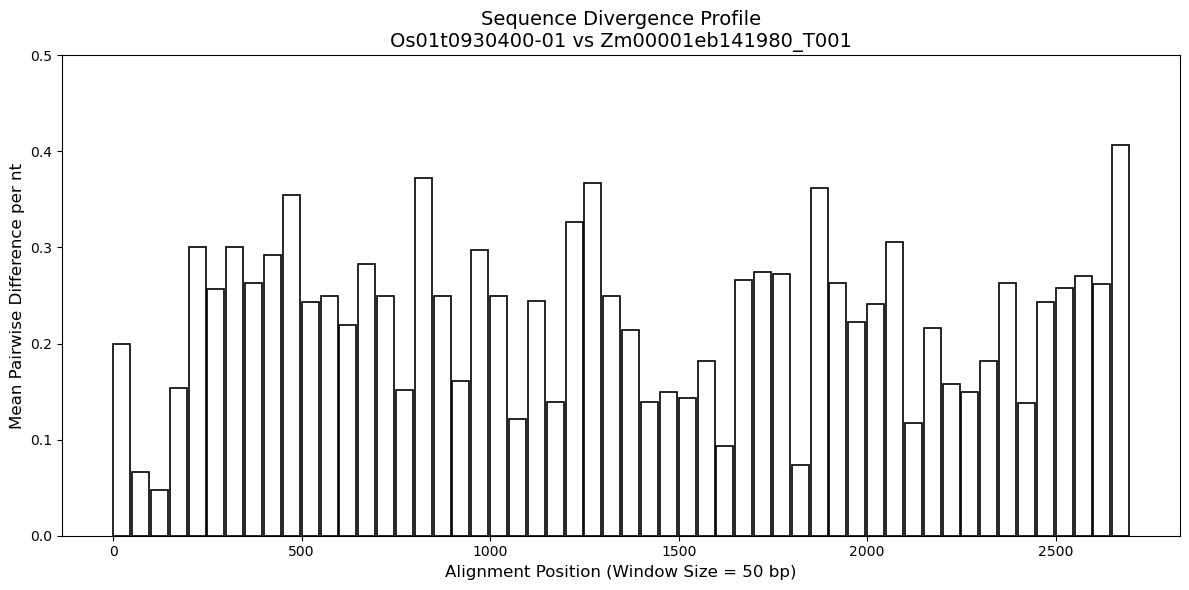

In [24]:
import pandas as pd
import io 
from Bio import SeqIO, Align
import matplotlib.pyplot as plt 

rice_id = "Os01t0930400-01"
maize_id = "Zm00001eb141980_T001"



print(f">>> 当前分析的目标基因对:")
print(f"    水稻: {rice_id}")
print(f"    玉米: {maize_id}")
print("-" * 40)

rice_fasta_file = "/data/user_home/2023122004/FFTransformer/data/Oryza/genome/Oryza_sativa.IRGSP-1.0.cds.all.fa"
maize_fasta_file = "/data/user_home/2023122004/FFTransformer/data/maize/genome/Zea_mays.Zm-B73-REFERENCE-NAM-5.0.cds.all.fa"

def get_sequence_by_id(fasta_file, target_id):
    try:
        record_dict = SeqIO.index(fasta_file, "fasta")
        
        if target_id in record_dict:
            return str(record_dict[target_id].seq)
        else:
            print(f"错误: 在 {fasta_file} 中找不到 ID: {target_id}")
            return None
    except FileNotFoundError:
        print(f"错误: 找不到文件 {fasta_file}")
        return None

print(">>> 正在提取序列...")
rice_seq = get_sequence_by_id(rice_fasta_file, rice_id)
maize_seq = get_sequence_by_id(maize_fasta_file, maize_id)

if not rice_seq or not maize_seq:
    print("!!! 警告: 未找到序列文件，流程终止。")
    exit()

def calculate_pairwise_diff_and_get_seqs(seq1, seq2):
    """
    执行全局比对，返回总体差异及对齐后的序列字符串
    """
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'
    aligner.match_score = 1.0
    aligner.mismatch_score = -2.0
    aligner.open_gap_score = -2.5
    aligner.extend_gap_score = -1.0
    
    alignments = aligner.align(seq1, seq2)
    try:
        best_aln = alignments[0]
    except IndexError:
        return 0, 0, 0, "", ""
    
    # 获取带 Gap 的序列字符串
    aln_fasta_str = format(best_aln, "fasta")
    with io.StringIO(aln_fasta_str) as handle:
        records = list(SeqIO.parse(handle, "fasta"))
        
    s1_final = str(records[0].seq)
    s2_final = str(records[1].seq)
    
    # --- 计算总体差异 ---
    mismatches = 0
    valid_sites = 0
    alignment_len = len(s1_final)
    
    for i in range(alignment_len):
        b1 = s1_final[i].upper()
        b2 = s2_final[i].upper()
        if b1 not in ['-', 'N'] and b2 not in ['-', 'N']:
            valid_sites += 1
            if b1 != b2:
                mismatches += 1
                
    mean_diff = mismatches / valid_sites if valid_sites > 0 else 0
    
    return mean_diff, valid_sites, mismatches, s1_final, s2_final

print(">>> 正在进行比对计算...")
diff, sites, mis, aln_seq1, aln_seq2 = calculate_pairwise_diff_and_get_seqs(rice_seq, maize_seq)

print("=" * 40)
print(f"【总体结果】")
print(f"每核苷酸平均差异 (Mean Diff per nt): {diff:.5f}")
print("=" * 40)

def sliding_window_and_plot(seq1_aln, seq2_aln, window_size=100):
    """
    每 100bp 切片计算差异度并绘图
    """
    x_positions = []
    y_diff_rates = []
    
    total_len = len(seq1_aln)

    for i in range(0, total_len, window_size):
        sub_s1 = seq1_aln[i : i + window_size]
        sub_s2 = seq2_aln[i : i + window_size]
        
        local_mismatches = 0
        local_valid = 0
        
        for b1, b2 in zip(sub_s1, sub_s2):
            b1, b2 = b1.upper(), b2.upper()
            if b1 not in ['-', 'N'] and b2 not in ['-', 'N']:
                local_valid += 1
                if b1 != b2:
                    local_mismatches += 1

        rate = local_mismatches / local_valid if local_valid > 0 else 0.0
        
        x_positions.append(i)
        y_diff_rates.append(rate)

    plt.figure(figsize=(12, 6))

    bars = plt.bar(x_positions, y_diff_rates, width=window_size*0.9, align='edge',
                   color='white', edgecolor='black', linewidth=1.2)
            
    plt.title(f"Sequence Divergence Profile\n{rice_id} vs {maize_id}", fontsize=14)
    plt.xlabel(f"Alignment Position (Window Size = {window_size} bp)", fontsize=12)
    plt.ylabel("Mean Pairwise Difference per nt", fontsize=12)

    max_y = max(y_diff_rates) if y_diff_rates else 0.5
    plt.ylim(0, max(0.5, max_y * 1.2))
    
    plt.tight_layout()

    # output_filename = f"divergence_{rice_id}_vs_{maize_id}.png"
    # plt.savefig(output_filename, dpi=300)
    # print(f">>> 图片已保存为: {output_filename}")
    # plt.show()

print(">>> 正在绘制滑窗分析图...")
sliding_window_and_plot(aln_seq1, aln_seq2, window_size=50)

In [25]:
target_gene_id = 'Zm00001eb141980'
gene_df = df_multi_sorf[df_multi_sorf['mazie_gene_ID'] == target_gene_id].copy()

gene_df = (
    gene_df
    .sort_values("pident", ascending=False)
    .drop_duplicates(
        subset=["qseqid", "sseqid", "mazie_gene_ID"],
        keep="first"
    )
)
print(gene_df['rice_DNA'].to_list())
gene_df


['ATGTTTCCCTCGAGTGAAGGTTGTCCACACATCAAGGTGGATCTATGGACAGATATACATTCCTGA', 'ATGCATTGTGTTGGTTGGTCTATTTGCATTGCAACACCGAGGTACTCAGAAGGTAGCGTTCATGTTTGCACCAATTGTCGTCATCTGGCTCTTTTGCATTGGTGGAATTGGTTTATACAACATAATACATTGGAACCCAAGGATATACCAAGCTCTCTCTCCATATTATATTGTTAA']


,qseqid,sseqid,pident,maize_DNA,mazie_gene_ID,maiza_gene_start,maiza_gene_end,maiza_gene_strand,rice_DNA,rice_gene_ID,rice_gene_start,rice_gene_end,rice_gene_strand
709,rice_sorf_1_15619,maize_sorf_3_7599,100.000,ATGCCATGCTTTGGGATGTTTCCCACGAGTGAAGGTTGTTCACACA...,Zm00001eb141980,156215870.0,156227435.0,+,ATGTTTCCCTCGAGTGAAGGTTGTCCACACATCAAGGTGGATCTAT...,Os01t0935500,41061106.0,41067020.0,+
703,rice_sorf_1_15617,maize_sorf_3_7597,87.931,GTGCATTGTGTTGGTTGGTCTATTTGCCTTGCAACACCGAGGTACT...,Zm00001eb141980,156215870.0,156227435.0,+,ATGCATTGTGTTGGTTGGTCTATTTGCATTGCAACACCGAGGTACT...,Os01t0935500,41061106.0,41067020.0,+


In [26]:
df_annotation=pd.read_csv('/data/user_home/2023122004/FFTransformer/protein/predict_sorf/maize/startCDS_with_Position.csv')

df_annotation['ID'] = df_annotation['ID'].astype(str)


# df_maize = df_maize.copy()
df_annotation['ID'] = df_annotation['ID'].astype(str).str.strip()
if not df_annotation['ID'].iloc[0].startswith('maize_'):
    df_annotation['ID'] = 'maize_' + df_annotation['ID']

# df_annotation['Ref_Feature_ID'] = (
#     df_annotation['Ref_Feature_ID']
#     .str.replace('CDS:', '', regex=True)
#     .str.split('_')
#     .str[0]
# )


target_gene_ids = [
    'maize_sorf_3_7599',
    'maize_sorf_3_7597' 
]

target_rows = df_annotation[
    df_annotation['ID'].isin(target_gene_ids)
]

target_rows['DNA_Sequence'].tolist()
target_rows

,ID,seqid,start,end,strand,Length_bp,Region_Category,CDS_Start_Status,Ref_Feature_ID,Ref_Feature_Coords,DNA_Sequence,attributes,CDS_Distance_bp,CDS_Relative_Pos,CDS_Relative_Pos_Formatted
25282,maize_sorf_3_7597,3,156224415,156224591,+,177,CDS,Internal_CDS,CDS:Zm00001eb141980_P001,3:156224396-156224656(+),GTGCATTGTGTTGGTTGGTCTATTTGCCTTGCAACACCGAGGTACT...,ID=sorf_3_7597;len=177;conf=1.00;start_codon=GTG,599.0,0.254677,0.2547
25284,maize_sorf_3_7599,3,156225758,156225892,+,135,CDS,Internal_CDS,CDS:Zm00001eb141980_P001,3:156225664-156225918(+),ATGCCATGCTTTGGGATGTTTCCCACGAGTGAAGGTTGTTCACACA...,ID=sorf_3_7599;len=135;conf=1.00;start_codon=ATG,1103.0,0.468963,0.4690


>>> 正在绘制滑窗分析图...
>>> 正在定位高亮区域...
    区间 1 映射成功: Alignment坐标 766 - 965
    区间 2 映射成功: Alignment坐标 1317 - 1462


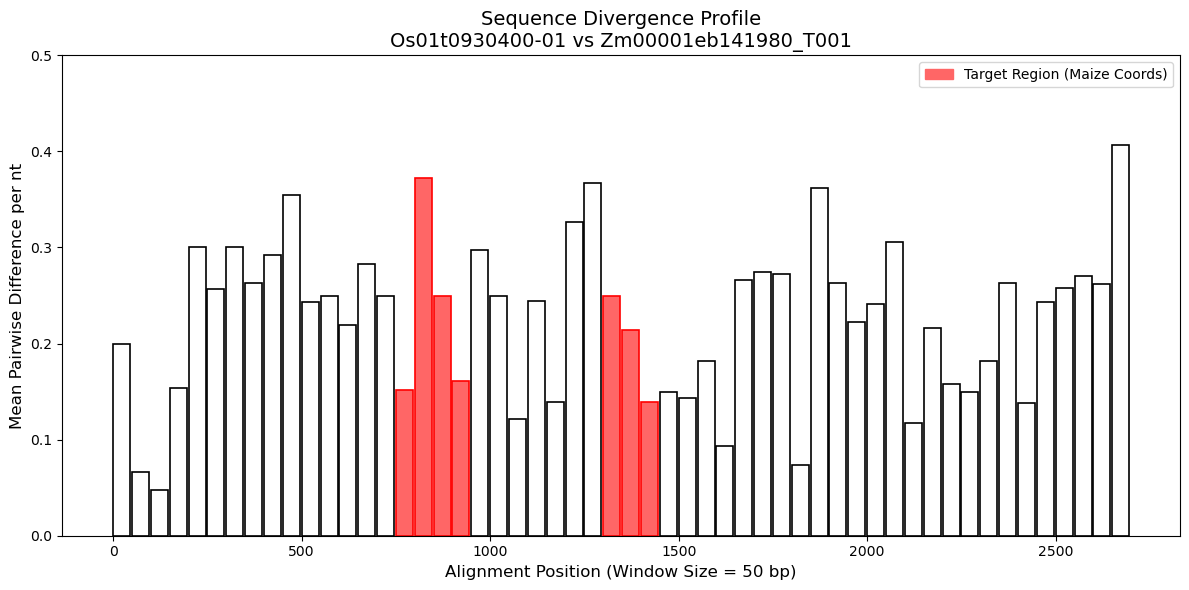

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def get_alignment_range_from_seq(raw_seq, aligned_seq, target_subseq):
    """
    核心功能：
    1. 在原始 CDS (raw_seq) 中找到子序列的位置。
    2. 将该位置映射到含 Gap 的比对序列 (aligned_seq) 的坐标轴上。
    """
    raw_seq_upper = raw_seq.upper()
    target_upper = target_subseq.upper()
    
    start_in_raw = raw_seq_upper.find(target_upper)
    
    if start_in_raw == -1:
        try:
            from Bio.Seq import Seq
            rc_target = str(Seq(target_upper).reverse_complement())
            start_in_raw = raw_seq_upper.find(rc_target)
            if start_in_raw != -1:
                print(f"提示: 在反向互补链中找到了序列片段 (长度 {len(target_subseq)})")
                target_upper = rc_target 
        except:
            pass

    if start_in_raw == -1:
        print(f"!!! 警告: 无法在 CDS 中找到该片段。可能是该片段位于内含子(Intron)中，或者跨越了剪接位点。")
        return None, None
    
    end_in_raw = start_in_raw + len(target_upper)
    
    aln_start = -1
    aln_end = -1

    non_gap_count = 0 
    
    for i, char in enumerate(aligned_seq):
        if char not in ['-', 'N']:
            if non_gap_count == start_in_raw:
                aln_start = i
            if non_gap_count == end_in_raw:
                aln_end = i
                break 
            non_gap_count += 1

    if aln_end == -1 and non_gap_count == end_in_raw:
        aln_end = len(aligned_seq)
        
    return aln_start, aln_end

def sliding_window_and_plot(seq1_aln, seq2_aln, raw_maize_seq, highlight_seqs=[], window_size=50):
    """
    highlight_seqs: 包含需要高亮的 DNA 序列字符串的列表
    """
    x_positions = []
    y_diff_rates = []
    total_len = len(seq1_aln)

    for i in range(0, total_len, window_size):
        sub_s1 = seq1_aln[i : i + window_size]
        sub_s2 = seq2_aln[i : i + window_size]
        local_mismatches = 0
        local_valid = 0
        for b1, b2 in zip(sub_s1, sub_s2):
            b1, b2 = b1.upper(), b2.upper()
            if b1 not in ['-', 'N'] and b2 not in ['-', 'N']:
                local_valid += 1
                if b1 != b2:
                    local_mismatches += 1
        rate = local_mismatches / local_valid if local_valid > 0 else 0.0
        x_positions.append(i)
        y_diff_rates.append(rate)

    plot_highlight_ranges = []
    print(">>> 正在定位高亮区域...")
    
    for idx, seq_frag in enumerate(highlight_seqs):

        s, e = get_alignment_range_from_seq(raw_maize_seq, seq2_aln, seq_frag)
        if s is not None:
            plot_highlight_ranges.append((s, e))
            print(f"    区间 {idx+1} 映射成功: Alignment坐标 {s} - {e}")

    plt.figure(figsize=(12, 6))

    bars = plt.bar(x_positions, y_diff_rates, width=window_size*0.9, align='edge',
                   color='white', edgecolor='black', linewidth=1.2)

    for bar, x_pos in zip(bars, x_positions):
        bar_center = x_pos + (window_size / 2)
        
        is_highlighted = False
        for (h_start, h_end) in plot_highlight_ranges:
            if h_start <= bar_center <= h_end:
                is_highlighted = True
                break
        
        if is_highlighted:
            bar.set_facecolor('#ff6666') # 红色
            bar.set_edgecolor('red')

    plt.title(f"Sequence Divergence Profile\n{rice_id} vs {maize_id}", fontsize=14)
    plt.xlabel(f"Alignment Position (Window Size = {window_size} bp)", fontsize=12)
    plt.ylabel("Mean Pairwise Difference per nt", fontsize=12)

    if plot_highlight_ranges:
        red_patch = mpatches.Patch(color='#ff6666', label='Target Region (Maize Coords)')
        plt.legend(handles=[red_patch])
    
    max_y = max(y_diff_rates) if y_diff_rates else 0.5
    plt.ylim(0, max(0.5, max_y * 1.2))
    plt.tight_layout()
    plt.show()

target_sequences = [
    "GTGCATTGTGTTGGTTGGTCTATTTGCCTTGCAACACCGAGGTACTCAGAAGGTTGCATTCGTGTTTGCACCCATTGTCATCATCTGGCTGCTTTCCATTGGAGGAATTGGTTTATACAACATTCTTCATTGGAATCCAAATATATATCAAGCTCTCTCTCCATATTATATGGTTAA", # <--- 替换为 156224415-156224591 的序列字符串
    "ATGCCATGCTTTGGGATGTTTCCCACGAGTGAAGGTTGTTCACACATCGAGGTGGATCTATGGGCAGATATATATTCCAGAAATAAATTGGATTCTTATGGTTCTTTGTGTTGCTGTCACTATTGCATTTCGTGA"  # <--- 替换为 156225758-156225892 的序列字符串
]

sliding_window_and_plot(aln_seq1, aln_seq2, 
                        raw_maize_seq=maize_seq, 
                        highlight_seqs=target_sequences, 
                        window_size=50)

>>> 开始绘制修正后的滑窗图...
>>> 1. 计算全局滑窗背景...
>>> 2. 正在进行 sORF 局部精细比对与替换...
    正在处理: sORF_1 (7597) (局部比对长度: 177 bp)
    正在处理: sORF_2 (7599) (局部比对长度: 135 bp)


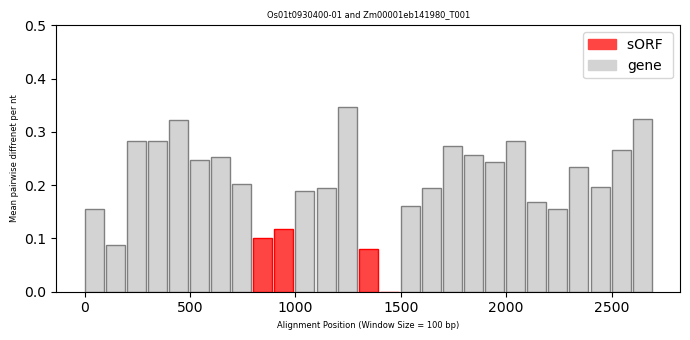

In [28]:
import pandas as pd
import io 
from Bio import SeqIO, Align
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import numpy as np


def get_local_alignment_seqs(seq1, seq2):
    """
    执行局部序列的全局比对，返回对齐后的两条字符串
    """
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'
    aligner.match_score = 1.0
    aligner.mismatch_score = -2.0
    aligner.open_gap_score = -2.5
    aligner.extend_gap_score = -1.0
    
    alignments = aligner.align(seq1, seq2)
    best_aln = alignments[0]
    
    aln_fasta_str = format(best_aln, "fasta")
    with io.StringIO(aln_fasta_str) as handle:
        records = list(SeqIO.parse(handle, "fasta"))
        
    return str(records[0].seq), str(records[1].seq)

def calculate_window_rate(seq_chunk1, seq_chunk2):
    """ 计算一个小窗口内的差异率 """
    mismatches = 0
    valid_sites = 0
    for b1, b2 in zip(seq_chunk1, seq_chunk2):
        b1, b2 = b1.upper(), b2.upper()
        if b1 not in ['-', 'N'] and b2 not in ['-', 'N']:
            valid_sites += 1
            if b1 != b2:
                mismatches += 1
    return mismatches / valid_sites if valid_sites > 0 else 0.0


def sliding_window_with_local_patch(seq1_aln, seq2_aln, raw_maize_seq, sorf_pairs, window_size=50):
    
    total_len = len(seq1_aln)
    x_positions = []
    y_diff_rates = []

    for i in range(0, total_len, window_size):
        sub_s1 = seq1_aln[i : i + window_size]
        sub_s2 = seq2_aln[i : i + window_size]
        y_diff_rates.append(calculate_window_rate(sub_s1, sub_s2))
        x_positions.append(i)
    
    highlighted_indices = set() 
    
    for pair in sorf_pairs:
        r_seq = pair['rice_subseq']
        m_seq = pair['maize_subseq']
        name = pair['name']

        loc_aln1, loc_aln2 = get_local_alignment_seqs(r_seq, m_seq)
        print(f"    正在处理: {name} (局部比对长度: {len(loc_aln1)} bp)")
        from Bio.Seq import Seq
        raw_maize_upper = raw_maize_seq.upper()
        m_seq_upper = m_seq.upper()
        
        # 查找位置
        start_in_raw = raw_maize_upper.find(m_seq_upper)
        if start_in_raw == -1:
            # 尝试反向
            rc_target = str(Seq(m_seq_upper).reverse_complement())
            start_in_raw = raw_maize_upper.find(rc_target)
            if start_in_raw != -1:
                m_seq_upper = rc_target 

        if start_in_raw == -1:
            print(f"    !!! 警告: 无法在基因组中定位 {name}，跳过。")
            continue
            
        end_in_raw = start_in_raw + len(m_seq_upper)
        
        # 映射到全局比对坐标 (Global Alignment Coordinates)
        global_aln_start = -1
        global_aln_end = -1
        non_gap_count = 0 
        for i, char in enumerate(seq2_aln):
            if char not in ['-', 'N']:
                if non_gap_count == start_in_raw:
                    global_aln_start = i
                if non_gap_count == end_in_raw:
                    global_aln_end = i
                    break 
                non_gap_count += 1
        
        if global_aln_start != -1:
            local_cursor = 0
            
            for idx, x_pos in enumerate(x_positions):
                bar_center = x_pos + (window_size / 2)
                if global_aln_start <= bar_center <= global_aln_end:
                    if local_cursor < len(loc_aln1):
                        sub_loc1 = loc_aln1[local_cursor : local_cursor + window_size]
                        sub_loc2 = loc_aln2[local_cursor : local_cursor + window_size]
                        refined_rate = calculate_window_rate(sub_loc1, sub_loc2)
                        y_diff_rates[idx] = refined_rate
                        highlighted_indices.add(idx)
                        local_cursor += window_size
                    else:
                        pass

    plt.figure(figsize=(7, 3.5))
    
    bars = plt.bar(x_positions, y_diff_rates, width=window_size*0.9, align='edge',
                   color='lightgray', edgecolor='grey', linewidth=1.0, label='Global Divergence')

    for idx in highlighted_indices:
        bars[idx].set_facecolor('#ff4444')
        bars[idx].set_edgecolor('red')
        bars[idx].set_alpha(1.0)

    plt.title(f"{rice_id} and {maize_id}", fontsize=6)
    plt.xlabel(f"Alignment Position (Window Size = {window_size} bp)", fontsize=6)
    plt.ylabel("Mean pairwise diffrenet per nt", fontsize=6)

    red_patch = mpatches.Patch(color='#ff4444', label='sORF ')
    gray_patch = mpatches.Patch(color='lightgray', label='gene')
    plt.legend(handles=[red_patch, gray_patch])
    
    # 动态调整Y轴
    max_y = max(y_diff_rates) if y_diff_rates else 0.5
    plt.ylim(0, max(0.5, max_y * 1.2))
    plt.tight_layout()
    plt.savefig('pairwise.png')
    plt.show()

sorf_data_pairs = [
    {
        "name": "sORF_1 (7597)",
        "rice_subseq": 'ATGCATTGTGTTGGTTGGTCTATTTGCATTGCAACACCGAGGTACTCAGAAGGTAGCGTTCATGTTTGCACCAATTGTCGTCATCTGGCTCTTTTGCATTGGTGGAATTGGTTTATACAACATAATACATTGGAACCCAAGGATATACCAAGCTCTCTCTCCATATTATATTGTTAA', 
        "maize_subseq": "GTGCATTGTGTTGGTTGGTCTATTTGCCTTGCAACACCGAGGTACTCAGAAGGTTGCATTCGTGTTTGCACCCATTGTCATCATCTGGCTGCTTTCCATTGGAGGAATTGGTTTATACAACATTCTTCATTGGAATCCAAATATATATCAAGCTCTCTCTCCATATTATATGGTTAA" 
    },
    {
        "name": "sORF_2 (7599)",
        "rice_subseq": 'ATGTTTCCCTCGAGTGAAGGTTGTCCACACATCAAGGTGGATCTATGGACAGATATACATTCCTGA',
        "maize_subseq": "ATGCCATGCTTTGGGATGTTTCCCACGAGTGAAGGTTGTTCACACATCGAGGTGGATCTATGGGCAGATATATATTCCAGAAATAAATTGGATTCTTATGGTTCTTTGTGTTGCTGTCACTATTGCATTTCGTGA"
    }
]


print(">>> 开始绘制修正后的滑窗图...")

sliding_window_with_local_patch(aln_seq1, aln_seq2, maize_seq, sorf_data_pairs, window_size=100)

>>> 开始绘制科研级图表...
>>> 1. 计算全局滑窗背景...
>>> 2. 计算 sORF 局部修正...
>>> 图片已保存: pairwise_divergence_pub_quality.png (300 DPI) & pairwise_divergence_pub_quality.pdf


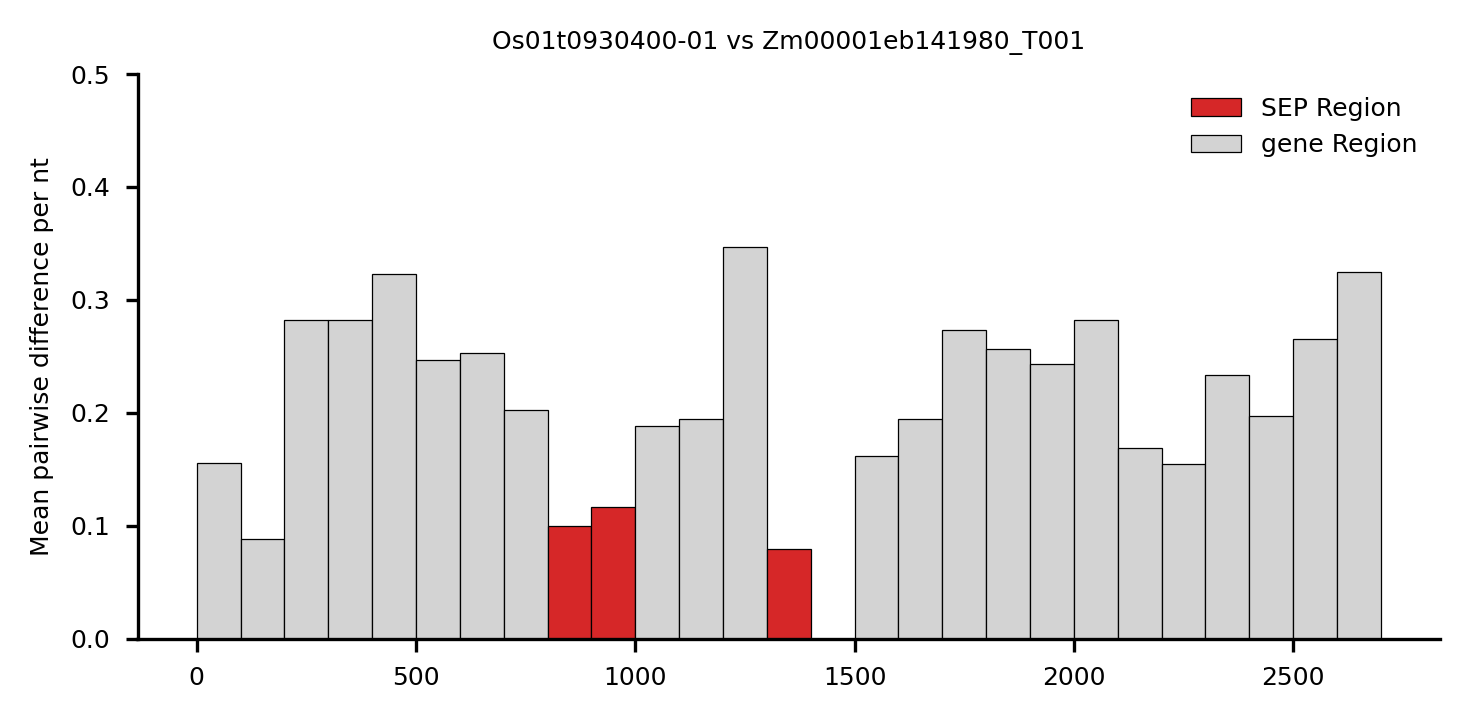

In [30]:
import pandas as pd
import io 
from Bio import SeqIO, Align
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import numpy as np


# 设置全局字体为 Arial (科研常用)，如果报错可改为 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['xtick.direction'] = 'out' # 刻度朝外
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['axes.linewidth'] = 0.8    # 坐标轴线宽


def get_local_alignment_seqs(seq1, seq2):
    """ 执行局部序列的全局比对 """
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'
    aligner.match_score = 1.0
    aligner.mismatch_score = -2.0
    aligner.open_gap_score = -2.5
    aligner.extend_gap_score = -1.0
    
    alignments = aligner.align(seq1, seq2)
    best_aln = alignments[0]
    
    aln_fasta_str = format(best_aln, "fasta")
    with io.StringIO(aln_fasta_str) as handle:
        records = list(SeqIO.parse(handle, "fasta"))
        
    return str(records[0].seq), str(records[1].seq)

def calculate_window_rate(seq_chunk1, seq_chunk2):
    """ 计算差异率 """
    mismatches = 0
    valid_sites = 0
    for b1, b2 in zip(seq_chunk1, seq_chunk2):
        b1, b2 = b1.upper(), b2.upper()
        if b1 not in ['-', 'N'] and b2 not in ['-', 'N']:
            valid_sites += 1
            if b1 != b2:
                mismatches += 1
    return mismatches / valid_sites if valid_sites > 0 else 0.0

def sliding_window_pub_quality(seq1_aln, seq2_aln, raw_maize_seq, sorf_pairs, window_size=50):

    total_len = len(seq1_aln)
    x_positions = []
    y_diff_rates = []

    for i in range(0, total_len, window_size):
        sub_s1 = seq1_aln[i : i + window_size]
        sub_s2 = seq2_aln[i : i + window_size]
        y_diff_rates.append(calculate_window_rate(sub_s1, sub_s2))
        x_positions.append(i)

    highlighted_indices = set() 
    
    for pair in sorf_pairs:
        r_seq = pair['rice_subseq']
        m_seq = pair['maize_subseq']
        name = pair['name']
        
        loc_aln1, loc_aln2 = get_local_alignment_seqs(r_seq, m_seq)

        from Bio.Seq import Seq
        raw_maize_upper = raw_maize_seq.upper()
        m_seq_upper = m_seq.upper()
        
        start_in_raw = raw_maize_upper.find(m_seq_upper)
        if start_in_raw == -1:
            rc_target = str(Seq(m_seq_upper).reverse_complement())
            start_in_raw = raw_maize_upper.find(rc_target)
            if start_in_raw != -1: m_seq_upper = rc_target

        if start_in_raw == -1: continue
            
        end_in_raw = start_in_raw + len(m_seq_upper)
        
        global_aln_start = -1
        global_aln_end = -1
        non_gap_count = 0 
        for i, char in enumerate(seq2_aln):
            if char not in ['-', 'N']:
                if non_gap_count == start_in_raw: global_aln_start = i
                if non_gap_count == end_in_raw: 
                    global_aln_end = i
                    break 
                non_gap_count += 1
        
        if global_aln_start != -1:
            local_cursor = 0
            for idx, x_pos in enumerate(x_positions):
                bar_center = x_pos + (window_size / 2)
                if global_aln_start <= bar_center <= global_aln_end:
                    if local_cursor < len(loc_aln1):
                        sub_loc1 = loc_aln1[local_cursor : local_cursor + window_size]
                        sub_loc2 = loc_aln2[local_cursor : local_cursor + window_size]
                        refined_rate = calculate_window_rate(sub_loc1, sub_loc2)
                        y_diff_rates[idx] = refined_rate
                        highlighted_indices.add(idx)
                        local_cursor += window_size

    fig, ax = plt.subplots(figsize=(5, 2.5), dpi=300) 

    color_bg = '#D3D3D3' 
    color_fg = '#D62728'  
    edge_color = 'black' 

    bars = ax.bar(x_positions, y_diff_rates, width=window_size*1.0, align='edge',
                  color=color_bg, edgecolor=edge_color, linewidth=0.3, label='Genome Region')

    for idx in highlighted_indices:
        bars[idx].set_facecolor(color_fg)
        bars[idx].set_edgecolor(edge_color)
        bars[idx].set_linewidth(0.3)
        bars[idx].set_alpha(1.0)

    ax.set_title(f"{rice_id} vs {maize_id}", fontsize=6)
    # ax.set_xlabel(f"Alignment Position (Window Size = {window_size} bp)", fontsize=6)
    ax.set_ylabel("Mean pairwise difference per nt", fontsize=6)

    ax.tick_params(axis='both', which='major', labelsize=6, width=0.8, length=3)

    max_y = max(y_diff_rates) if y_diff_rates else 0.5
    ax.set_ylim(0, max(0.5, max_y * 1.15))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    legend_patches = [
        mpatches.Patch(facecolor=color_fg, edgecolor=edge_color, linewidth=0.3, label='SEP Region'),
        mpatches.Patch(facecolor=color_bg, edgecolor=edge_color, linewidth=0.3, label='gene Region')
    ]

    ax.legend(handles=legend_patches, loc='upper right', fontsize=6, frameon=False)

    plt.tight_layout() 

    output_name = "pairwise_divergence_pub_quality"
    plt.savefig(f'{output_name}.pdf', format='pdf', bbox_inches='tight')
    plt.savefig(f'{output_name}.png', format='png', dpi=1300, bbox_inches='tight')
    plt.savefig(f'{output_name}.svg', format='svg', dpi=1300, bbox_inches='tight')
    
    print(f">>> 图片已保存: {output_name}.png (300 DPI) & {output_name}.pdf")
    plt.show()

sliding_window_pub_quality(aln_seq1, aln_seq2, maize_seq, sorf_data_pairs, window_size=100)